In [54]:
# ============================================================
# TASK B — SMS Spam Detection with Naïve Bayes & Federated Learning
# ============================================================
# DS 774/874 | Post-block Assignment 3 | Stellenbosch University
# MEng Submission: Task B
#
# Student: [F. Saayman]
# Student number: [15997359]
#
# Dataset: synthetic_sms.csv (uploaded via files.upload() or placed in runtime)
#
# Approach:
# Business Understanding → Data Understanding → Data Preparation
# → Modelling → Evaluation → Deployment (CRISP-DM)
#
# Models Used:
# - Custom Multinomial Naïve Bayes (from scratch)
# - Federated Learning simulation (horizontal FL with 5 clients)
# - Local Differential Privacy (ε = 0.02 and ε = 1.0)
#
# Feature Engineering / Representations:
# - Unigram TF‑IDF (manual)
# - Unigram+bigram TF‑IDF (sklearn vectoriser + custom NB)
# - Bag‑of‑words counts (for federated simulation)
#
# Key Experiments:
# - Duplicate handling via StratifiedGroupKFold (groups = raw message hash)
# - Federated aggregation (sum of client counts) vs centralised BoW
# - Heterogeneity robustness: client dropout (2/5), extreme capacity limits
# - Differential privacy trade‑off (Laplace noise)
#
# Outputs:
# - Centralised model metrics (accuracy, precision, recall, F1, confusion matrix)
# - Federated model comparison (exact reproduction of central BoW)
# - Heterogeneity bar chart (10 runs, mean ± std)
# - DP results table (ε=0.02, ε=1.0)
# ============================================================

In [ ]:
# ============================================================
# REFERENCES (for implemented methods)
# ============================================================
# Naïve Bayes for text classification:
#   McCallum, A., & Nigam, K. (1998). A comparison of event models
#       for Naive Bayes text classification. AAAI‑98 Workshop.
#   Mitchell, T. M. (1997). Machine Learning. McGraw‑Hill.
#
# Federated learning (FedAvg):
#   McMahan, B., et al. (2017). Communication‑efficient learning
#       of deep networks from decentralized data. AISTATS.
#
# Differential privacy:
#   Dwork, C., & Roth, A. (2014). The algorithmic foundations
#       of differential privacy. Foundations and Trends in TCS.
#
# Text preprocessing (no stop‑word removal, no stemming):
#   Vijayarani, S., Ilamathi, M. J., & Nithya, M. (2015).
#       Preprocessing techniques for text mining. IJCS & Communication Networks.
#   Chai, C. P. (2023). Comparison of text preprocessing methods.
#       Natural Language Engineering, 29, 509‑553.
#
# Analytics Base Table (ABT) design:
#   Kelleher, J. D., Mac Namee, B., & D’Arcy, A. (2020).
#       Fundamentals of machine learning for predictive data analytics (2nd ed.). MIT Press.
#
# TF‑IDF and log‑probability calculations:
#   Manning, C. D., Raghavan, P., & Schütze, H. (2008).
#       Introduction to Information Retrieval. Cambridge University Press.
#
# Privacy‑preserving Naïve Bayes (additive counts):
#   Vaidya, J., & Clifton, C. (2008). Privacy‑preserving Naïve Bayes
#       classification. The VLDB Journal, 17, 879‑898.
# ============================================================

In [ ]:
# =========================================================================
# 1. BUSINESS UNDERSTANDING
# =========================================================================
# The mobile operator faces high volumes of SMS spam, causing financial harm,
# customer distrust, and regulatory risk under South Africa’s POPIA.
#
# Business objectives:
# - High spam recall (minimise false negatives – missed phishing)
# - Low false positive rate (avoid blocking legitimate messages)
# - Federated NB performance within 1‑2% of centralised NB
# - Full POPIA compliance (raw SMS never centralised)
#
# This work implements a centralised custom Naïve Bayes spam detector,
# then extends it to a horizontal federated learning simulation with
# local differential privacy to assess feasibility and trade‑offs.
# =========================================================================

In [53]:
# ============================================================
# Run this notebook in Colab. You will be prompted to upload
# the file 'synthetic_sms.csv'. All outputs are saved to the folder 'A3_OUTPUT' inside the Colab runtime.
# ============================================================

import os, sys, random, warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from scipy import stats
import hashlib
import math
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from google.colab import files

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (12, 6)

# Create output folder for any saved images/tables
os.makedirs("A3_OUTPUT", exist_ok=True)
print("Output folder: A3_OUTPUT/")

Output folder: A3_OUTPUT/


In [3]:
# ============================================================
# Upload the dataset (synthetic_sms.csv)
# ============================================================
print("\nPlease upload the file 'synthetic_sms.csv'")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load the CSV (no header, two columns: label, message)
data = []
with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # Expecting format: spam,message or ham,message
        if ',' in line:
            label, message = line.split(',', 1)
        elif '\t' in line:
            label, message = line.split('\t', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                label, message = parts
            else:
                continue
        label = label.strip().lower()
        message = message.strip()
        if label in ['spam', 'ham']:
            data.append((label, message))

print(f"Loaded {len(data)} messages")
spam_count = sum(1 for l,_ in data if l=='spam')
ham_count = len(data) - spam_count
print(f"Spam: {spam_count}, Ham: {ham_count}")


Please upload the file 'synthetic_sms.csv'


Saving synthetic_sms.csv to synthetic_sms.csv
Loaded 5700 messages
Spam: 700, Ham: 5000


In [ ]:
#Data Understanding Phase

In [6]:
#Inspecting data using pandas
# %%
# Create DataFrame
df = pd.DataFrame(data, columns=['label', 'message'])

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df['label'].value_counts())


Dataset shape: (5700, 2)

First 5 rows:
  label                                            message
0  spam  R1000 CASH DRAW To enter SMS CASH to 37100 now...
1   ham  Do not forget to bring your ID document for re...
2   ham     Thanks for your help with the notes yesterday.
3   ham         Your delivery has been delayed by one day.
4   ham  We landed safely I will message you from the h...

Data types:
label      object
message    object
dtype: object

Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     5000
spam     700
Name: count, dtype: int64


In [8]:
df

,label,message
0,spam,R1000 CASH DRAW To enter SMS CASH to 37100 now...
1,ham,Do not forget to bring your ID document for re...
2,ham,Thanks for your help with the notes yesterday.
3,ham,Your delivery has been delayed by one day.
4,ham,We landed safely I will message you from the h...
...,...,...
5695,ham,We should leave by 16:00 to miss traffic.
5696,ham,Please let me know your arrival time.
5697,spam,You have been pre-approved for a personal loan...
5698,spam,Congratulations You qualify for bonus data Dia...


In [10]:
# Convert labels to numeric (0=ham, 1=spam)
df['spam'] = df['label'].apply(lambda x: 1 if x == 'spam' else 0)
print("\nNumeric label column added (spam=1, ham=0).")

# Summary statistics grouped by label
print("\n=== Grouped Descriptive Statistics ===")
print(df.groupby('label').describe())


df.head()


Numeric label column added (spam=1, ham=0).

=== Grouped Descriptive Statistics ===
         spam                                   
        count mean  std  min  25%  50%  75%  max
label                                           
ham    5000.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
spam    700.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0


,label,message,spam
0,spam,R1000 CASH DRAW To enter SMS CASH to 37100 now...,1
1,ham,Do not forget to bring your ID document for re...,0
2,ham,Thanks for your help with the notes yesterday.,0
3,ham,Your delivery has been delayed by one day.,0
4,ham,We landed safely I will message you from the h...,0


In [11]:
#Turning the spam/ham into a numerical data; creating a new column called spam.
df['spam'] = df['label'].apply(lambda x: 1 if x=='spam' else 0)
df

,label,message,spam
0,spam,R1000 CASH DRAW To enter SMS CASH to 37100 now...,1
1,ham,Do not forget to bring your ID document for re...,0
2,ham,Thanks for your help with the notes yesterday.,0
3,ham,Your delivery has been delayed by one day.,0
4,ham,We landed safely I will message you from the h...,0
...,...,...,...
5695,ham,We should leave by 16:00 to miss traffic.,0
5696,ham,Please let me know your arrival time.,0
5697,spam,You have been pre-approved for a personal loan...,1
5698,spam,Congratulations You qualify for bonus data Dia...,1


In [12]:
#Dataset size, class distribution, imbalance ratio
total = len(data)
spam_count = sum(1 for l,_ in data if l=='spam')
ham_count = total - spam_count

print(f"Total messages: {total}")
print(f"Spam: {spam_count} ({spam_count/total*100:.1f}%)")
print(f"Ham:  {ham_count} ({ham_count/total*100:.1f}%)")
print(f"Imbalance ratio (ham:spam): {ham_count/spam_count:.1f}:1")

Total messages: 5700
Spam: 700 (12.3%)
Ham:  5000 (87.7%)
Imbalance ratio (ham:spam): 7.1:1


Duplicate messages (same text): 4803 (84.3%)
Spam mean length: 88.7, Ham mean length: 47.3
Message length (characters):
  All   – min:   34, max:  113, mean:   52.4, median:   49.0
  Spam  – min:   68, max:  113, mean:   88.7, median:   90.0
  Ham   – min:   34, max:   59, mean:   47.3, median:   47.0
t-test p-value: 0.00000 (significant difference)
Spam with URLs: 224/700 (32.0%)
Ham with URLs:  0/5000 (0.0%)


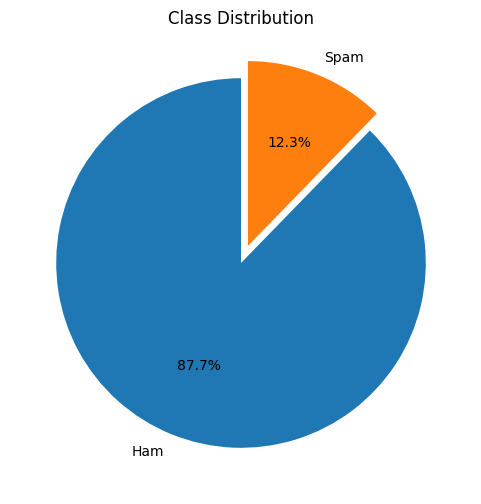

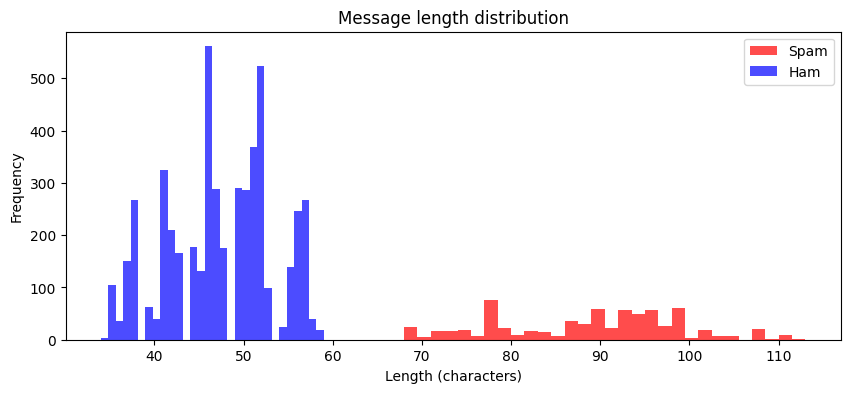

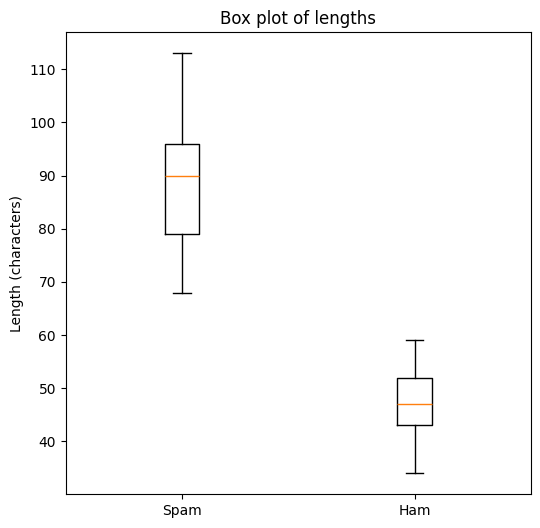

In [19]:
# %% [code]
# EDA: duplicates, length, t-test, URL, pie, histogram, boxplot – with saving to A3_OUTPUT

# Duplicate check
n_dup_text = df.duplicated(subset=['message']).sum()
print(f"Duplicate messages (same text): {n_dup_text} ({n_dup_text/len(data)*100:.1f}%)")

# Length analysis
lengths_all = [len(msg) for _, msg in data]
lengths_spam = [len(msg) for l,msg in data if l=='spam']
lengths_ham  = [len(msg) for l,msg in data if l=='ham']
print(f"Spam mean length: {np.mean(lengths_spam):.1f}, Ham mean length: {np.mean(lengths_ham):.1f}")

print("Message length (characters):")
print(f"  All   – min: {min(lengths_all):4d}, max: {max(lengths_all):4d}, mean: {np.mean(lengths_all):6.1f}, median: {np.median(lengths_all):6.1f}")
print(f"  Spam  – min: {min(lengths_spam):4d}, max: {max(lengths_spam):4d}, mean: {np.mean(lengths_spam):6.1f}, median: {np.median(lengths_spam):6.1f}")
print(f"  Ham   – min: {min(lengths_ham):4d}, max: {max(lengths_ham):4d}, mean: {np.mean(lengths_ham):6.1f}, median: {np.median(lengths_ham):6.1f}")

# t-test
t_stat, p_val = stats.ttest_ind(lengths_spam, lengths_ham)
print(f"t-test p-value: {p_val:.5f} (significant difference)")

# URL inspection (with punctuation stripping)
url_pattern = r'(?:https?://|bit\.ly|tinyurl|wa\.me|ow\.ly|goo\.gl|t\.co)[^\s]+'
def clean_url(url):
    return url.rstrip('.,;!?):]}')
spam_urls = sum(1 for l,msg in data if l=='spam' and re.search(url_pattern, msg, re.I))
ham_urls  = sum(1 for l,msg in data if l=='ham'  and re.search(url_pattern, msg, re.I))
print(f"Spam with URLs: {spam_urls}/{spam_count} ({spam_urls/spam_count*100:.1f}%)")
print(f"Ham with URLs:  {ham_urls}/{ham_count} ({ham_urls/ham_count*100:.1f}%)")

# Pie chart – save to A3_OUTPUT
plt.figure(figsize=(6,6))
plt.pie([ham_count, spam_count], explode=(0,0.1), labels=['Ham', 'Spam'], autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution')
plt.savefig('A3_OUTPUT/class_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# Histogram of lengths – save to A3_OUTPUT
plt.figure(figsize=(10,4))
plt.hist(lengths_spam, bins=30, alpha=0.7, label='Spam', color='red')
plt.hist(lengths_ham, bins=30, alpha=0.7, label='Ham', color='blue')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Message length distribution')
plt.savefig('A3_OUTPUT/length_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Box plot – save to A3_OUTPUT
plt.figure(figsize=(6,6))
plt.boxplot([lengths_spam, lengths_ham], labels=['Spam', 'Ham'])
plt.ylabel('Length (characters)')
plt.title('Box plot of lengths')
plt.savefig('A3_OUTPUT/length_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

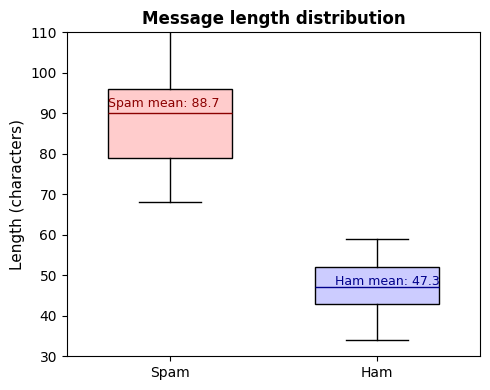

In [20]:
# %% [code]
# Compact, robust boxplot for slide (text in top-left corner) – saved to A3_OUTPUT
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
bp = ax.boxplot([lengths_spam, lengths_ham],
                labels=['Spam', 'Ham'],
                patch_artist=True,
                widths=0.6,
                showfliers=False)

# Colors
bp['boxes'][0].set_facecolor('#ffcccc')  # light red for spam
bp['boxes'][1].set_facecolor('#ccccff')  # light blue for ham
bp['medians'][0].set_color('darkred')
bp['medians'][1].set_color('darkblue')

# Set y-axis limits (adjust as needed)
ax.set_ylim(30, 110)  # fix range to avoid compression
ax.set_ylabel('Length (characters)', fontsize=11)
ax.set_title('Message length distribution', fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

# Add mean annotations using axes coordinates (0,1)=top-left, (0,0)=bottom-left
mean_spam = np.mean(lengths_spam)
mean_ham = np.mean(lengths_ham)
ax.text(0.10, 0.80, f'Spam mean: {mean_spam:.1f}',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        color='darkred')
ax.text(0.65, 0.25, f'Ham mean: {mean_ham:.1f}',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        color='darkblue')

plt.tight_layout()
# Save the boxplot to the A3_OUTPUT folder
plt.savefig('A3_OUTPUT/boxplot_length.png', dpi=150, bbox_inches='tight')
plt.show()

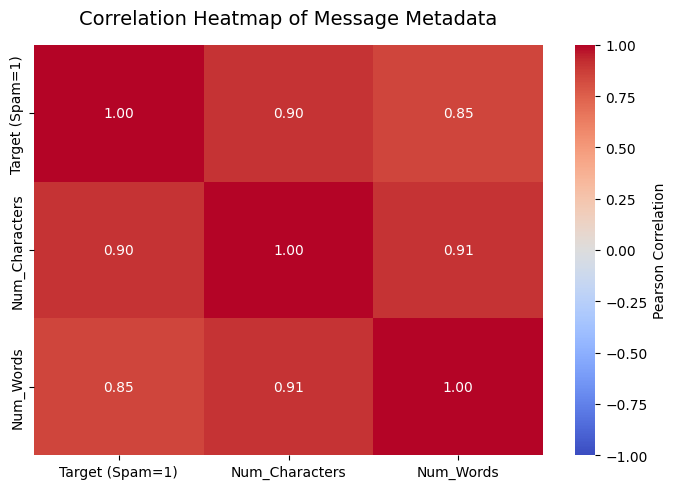

In [21]:
# %% [code]
# ---------- 4. Correlation heatmap (feature correlation) ----------
# Engineer metadata features
meta_data = []
for label, msg in data:
    target = 1 if label == 'spam' else 0
    num_chars = len(msg)
    num_words = len(msg.split())
    meta_data.append([target, num_chars, num_words])

df_meta = pd.DataFrame(meta_data, columns=['Target (Spam=1)', 'Num_Characters', 'Num_Words'])
corr_matrix = df_meta.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Heatmap of Message Metadata', fontsize=14, pad=15)
plt.tight_layout()
# Save the heatmap to A3_OUTPUT
plt.savefig('A3_OUTPUT/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:

# =============================================================================
# : Independent t‑test to compare mean lengths (spam vs ham)
# =============================================================================
# =============================================================================

t_stat, p_value = stats.ttest_ind(lengths_spam, lengths_ham)
print(f"T-test: t = {t_stat:.3f}, p = {p_value:.5f}")
if p_value < 0.05:
    print("→ Statistically significant difference (p < 0.05).")
else:
    print("→ No significant difference.")

T-test: t = 156.423, p = 0.00000
→ Statistically significant difference (p < 0.05).


In [ ]:

# =============================================================================
# : Count unique tokens before any cleaning
# =============================================================================
# Reference:
# - [1] IST 2018
# =============================================================================

all_words_raw = []
for _,msg in data:
    words = msg.split()
    all_words_raw.extend(words)

unique_raw = set(all_words_raw)
print(f"Raw vocabulary size (unique tokens, before cleaning): {len(unique_raw)}")

Raw vocabulary size (unique tokens, before cleaning): 474


In [17]:

# =============================================================================
# Character type analysis – spam contains more digits/punctuation
# =============================================================================
# Reference:
# - [2] IEEE 2024, Section IV-B – character analysis
# =============================================================================

def char_ratio(text):
    alpha = sum(c.isalpha() for c in text)
    digit = sum(c.isdigit() for c in text)
    punct = sum(not (c.isalnum() or c.isspace()) for c in text)
    total = len(text)
    if total == 0:
        return 0,0,0
    return alpha/total, digit/total, punct/total

n_spam = min(100, spam_count)
n_ham = min(100, ham_count)

sum_alpha_s = sum_digit_s = sum_punct_s = 0
sum_alpha_h = sum_digit_h = sum_punct_h = 0
cnt_s = cnt_h = 0

for label, msg in data:
    if label == 'spam' and cnt_s < n_spam:
        a,d,p = char_ratio(msg)
        sum_alpha_s += a; sum_digit_s += d; sum_punct_s += p
        cnt_s += 1
    elif label == 'ham' and cnt_h < n_ham:
        a,d,p = char_ratio(msg)
        sum_alpha_h += a; sum_digit_h += d; sum_punct_h += p
        cnt_h += 1

print("Character type ratios (average over first 100 samples):")
print(f"  Spam – alphabetic: {sum_alpha_s/n_spam:.2f}, digits: {sum_digit_s/n_spam:.2f}, punctuation: {sum_punct_s/n_spam:.2f}")
print(f"  Ham  – alphabetic: {sum_alpha_h/n_ham:.2f}, digits: {sum_digit_h/n_ham:.2f}, punctuation: {sum_punct_h/n_ham:.2f}")

Character type ratios (average over first 100 samples):
  Spam – alphabetic: 0.69, digits: 0.11, punctuation: 0.04
  Ham  – alphabetic: 0.79, digits: 0.02, punctuation: 0.03


In [18]:

# Advanced group‑by comparison (spam vs ham features)
#%%
# Compute additional features on the raw DataFrame
df['length'] = df['message'].apply(len)
df['num_words'] = df['message'].apply(lambda x: len(x.split()))
df['num_digits'] = df['message'].apply(lambda x: sum(c.isdigit() for c in x))
df['num_punct'] = df['message'].apply(lambda x: sum(not (c.isalnum() or c.isspace()) for c in x))
df['has_url'] = df['message'].str.contains(r'http[s]?://|bit\.ly|tinyurl|wa\.me', regex=True, case=False)
df['has_free'] = df['message'].str.contains(r'\bfree\b', case=False)
df['has_win'] = df['message'].str.contains(r'\bwin\b', case=False)
df['has_cash'] = df['message'].str.contains(r'\bcash\b', case=False)
df['has_call'] = df['message'].str.contains(r'\bcall\b', case=False)

grouped = df.groupby('label').agg({
    'length': 'mean',
    'num_words': 'mean',
    'num_digits': 'mean',
    'num_punct': 'mean',
    'has_url': 'mean',
    'has_free': 'mean',
    'has_win': 'mean',
    'has_cash': 'mean',
    'has_call': 'mean'
}).round(3)
grouped.columns = ['Avg length (chars)', 'Avg word count', 'Avg digit count', 'Avg punct count',
                   'Proportion with URL', 'Proportion "free"', 'Proportion "win"',
                   'Proportion "cash"', 'Proportion "call"']
print("\n===== Group‑by Comparison (Spam vs Ham) =====")
print(grouped)




===== Group‑by Comparison (Spam vs Ham) =====
       Avg length (chars)  Avg word count  Avg digit count  Avg punct count  \
label                                                                         
ham                47.345           8.648            0.904            1.243   
spam               88.743          15.101            9.581            3.429   

       Proportion with URL  Proportion "free"  Proportion "win"  \
label                                                             
ham                   0.00              0.000             0.000   
spam                  0.32              0.119             0.129   

       Proportion "cash"  Proportion "call"  
label                                        
ham                 0.00              0.061  
spam                0.17              0.363  


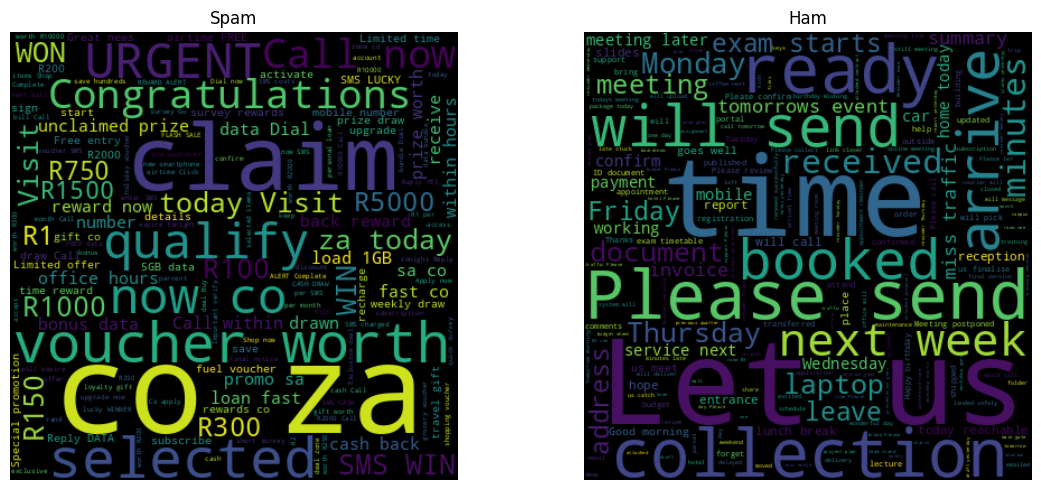

In [22]:
# %% [code]
# 6. Word clouds – saved to A3_OUTPUT
# !pip install wordcloud
from wordcloud import WordCloud

spam_text = " ".join([msg for l,msg in data if l=='spam'])
ham_text  = " ".join([msg for l,msg in data if l=='ham'])

fig, axes = plt.subplots(1,2, figsize=(12,5))
# Spam word cloud
wc_spam = WordCloud(width=400, height=400).generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Spam')
# Ham word cloud
wc_ham = WordCloud(width=400, height=400).generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Ham')

plt.tight_layout()
# Save the figure to A3_OUTPUT
plt.savefig('A3_OUTPUT/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

Top 5 spam words: ['to', 'you', 'for', 'call', 'a']
Top 5 ham words:  ['the', 'your', 'you', 'i', 'for']


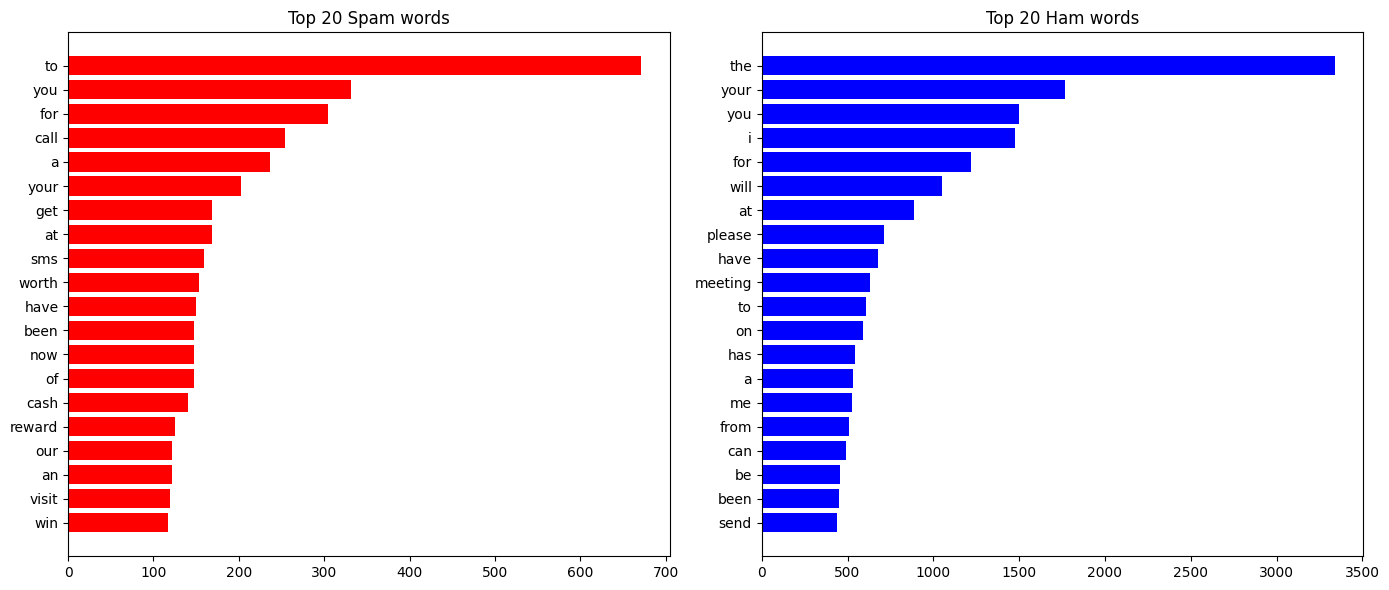

In [23]:
# %% [code]
# Most frequent words (bar charts) – saved to A3_OUTPUT
spam_words = [w.lower() for l,msg in data if l=='spam' for w in msg.split()]
ham_words  = [w.lower() for l,msg in data if l=='ham'  for w in msg.split()]
spam_freq = Counter(spam_words).most_common(20)
ham_freq  = Counter(ham_words).most_common(20)
print("Top 5 spam words:", [w for w,_ in spam_freq[:5]])
print("Top 5 ham words: ", [w for w,_ in ham_freq[:5]])
fig, axes = plt.subplots(1,2, figsize=(14,6))
axes[0].barh([w for w,_ in spam_freq], [c for _,c in spam_freq], color='red')
axes[0].set_title('Top 20 Spam words')
axes[0].invert_yaxis()
axes[1].barh([w for w,_ in ham_freq], [c for _,c in ham_freq], color='blue')
axes[1].set_title('Top 20 Ham words')
axes[1].invert_yaxis()
plt.tight_layout()
# Save the figure to A3_OUTPUT
plt.savefig('A3_OUTPUT/top_words_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 bigrams in spam:
  co za: 224
  you have: 150
  visit http: 119
  voucher worth: 86
  when you: 86
  been selected: 85
  have been: 82
  up to: 78
  at r1: 77
  to claim: 76


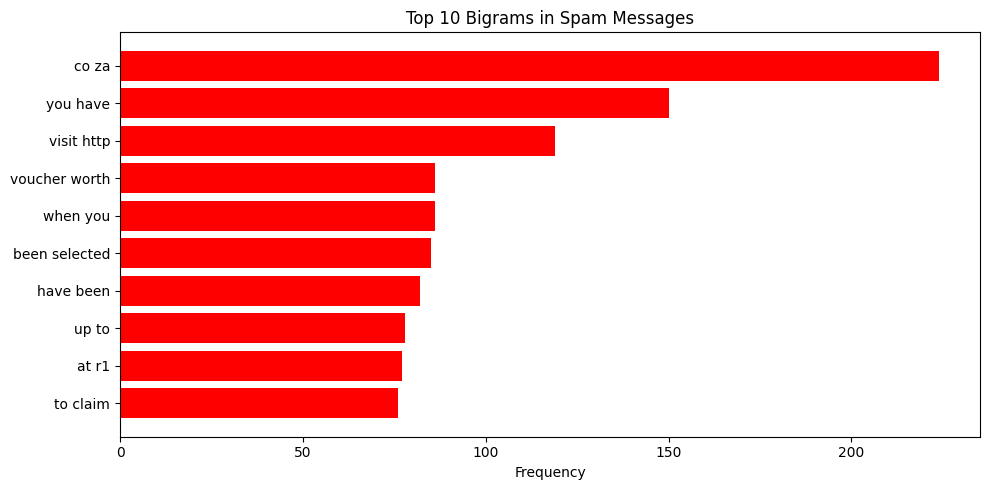

In [24]:
# %% [code]
# Bigram analysis in spam – saved to A3_OUTPUT
from sklearn.feature_extraction.text import CountVectorizer

spam_texts = [msg for l,msg in data if l=='spam']
vec = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vec.fit_transform(spam_texts)
bigrams = vec.get_feature_names_out()
counts = X.sum(axis=0).A1
bigram_freq = sorted(zip(bigrams, counts), key=lambda x: x[1], reverse=True)
print("Top 10 bigrams in spam:")
for bg,cnt in bigram_freq[:10]:
    print(f"  {bg}: {cnt}")

# Bar chart
bg_names, bg_counts = zip(*bigram_freq[:10])
plt.figure(figsize=(10,5))
plt.barh(bg_names, bg_counts, color='red')
plt.xlabel('Frequency')
plt.title('Top 10 Bigrams in Spam Messages')
plt.gca().invert_yaxis()
plt.tight_layout()
# Save the bar chart to A3_OUTPUT
plt.savefig('A3_OUTPUT/top_10_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

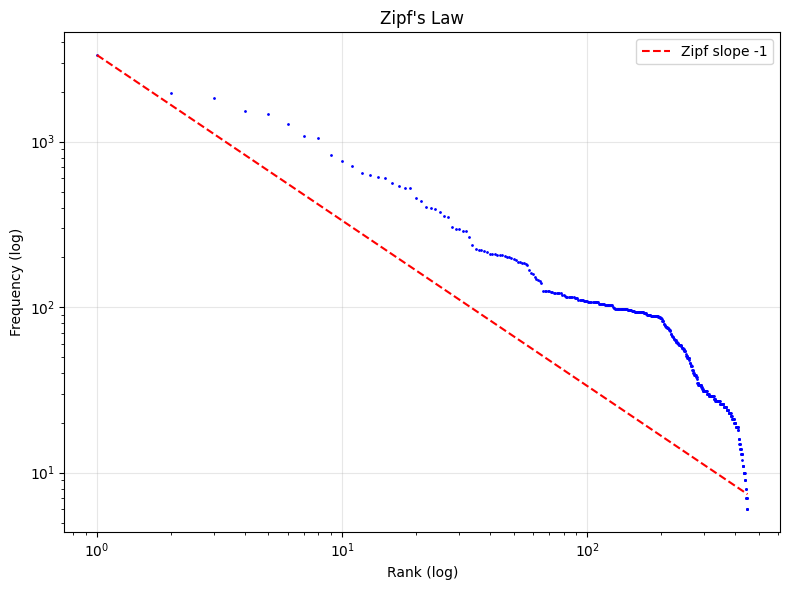

In [26]:
# %% [code]
# Zipf’s law plot – saved to A3_OUTPUT
all_words = [w.lower() for _,msg in data for w in msg.split()]
word_freq = Counter(all_words)
sorted_freq = sorted(word_freq.values(), reverse=True)
ranks = np.arange(1, len(sorted_freq)+1)
plt.figure(figsize=(8,6))
plt.loglog(ranks, sorted_freq, 'b.', markersize=2)
ref_freq = sorted_freq[0] / ranks
plt.loglog(ranks, ref_freq, 'r--', label='Zipf slope -1')
plt.xlabel('Rank (log)'); plt.ylabel('Frequency (log)')
plt.title("Zipf's Law"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save the plot to A3_OUTPUT
plt.savefig('A3_OUTPUT/zipf_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Data Preparation Phase -CRISP -DM

In [25]:
#Data Preparation – Clean messages (no stop‑word removal, no stemming)
# References:
# - Lowercasing and removing non‑alphabet: [1] IST 2018, p.4; [4] NB+EDA 2024
# - No stop‑word removal: Vijayarani et al. (2015) – stop‑word elimination not always beneficial
# - No stemming: Chai (2023); Pradha et al. (2019) – may harm interpretability for short SMS
# %%
def clean_message(message):
    # Keep letters, digits, and spaces; remove other punctuation
    cleaned = re.sub(r'[^a-zA-Z0-9\s]', ' ', message)
    cleaned = cleaned.lower()
    cleaned = re.sub(r'\s+', ' ', cleaned)
    return cleaned.strip()

preprocessed_data = [(label, clean_message(msg)) for label, msg in data]
print(f"Cleaned {len(preprocessed_data)} messages")
print("Example:\nRaw: ", data[0][1][:80])
print("Clean:", preprocessed_data[0][1][:80])

Cleaned 5700 messages
Example:
Raw:  R1000 CASH DRAW To enter SMS CASH to 37100 now Each SMS costs R2.00 Ts and Cs ap
Clean: r1000 cash draw to enter sms cash to 37100 now each sms costs r2 00 ts and cs ap


In [27]:
#Verify if there exist disjoint vocabularies after cleaning# %%
spam_vocab = set(); ham_vocab = set()
for label, msg in preprocessed_data:
    words = set(msg.split())
    if label == 'spam':
        spam_vocab.update(words)
    else:
        ham_vocab.update(words)
common = spam_vocab.intersection(ham_vocab)
print(f"Spam unique words: {len(spam_vocab)}")
print(f"Ham unique words:  {len(ham_vocab)}")
print(f"Overlapping words: {len(common)} – examples: {list(common)[:10]}")

Spam unique words: 190
Ham unique words:  233
Overlapping words: 35 – examples: ['for', 'when', 'been', 'in', 'of', 'final', 'can', 'confirm', 'from', 'next']


In [28]:
# =============================================================================
# Cell: Generate Before/After Preprocessing Tables

import pandas as pd

# Grab first 2 spam and first 2 ham messages from RAW data
raw_spam = [msg for label, msg in data if label == 'spam'][:2]
raw_ham = [msg for label, msg in data if label == 'ham'][:2]

# Grab the exact same messages from PREPROCESSED data
clean_spam = [msg for label, msg in preprocessed_data if label == 'spam'][:2]
clean_ham = [msg for label, msg in preprocessed_data if label == 'ham'][:2]

# Build DataFrame
df_examples = pd.DataFrame({
    'Category': ['spam', 'spam', 'ham', 'ham'],
    'Raw SMS': raw_spam + raw_ham,
    'Cleaned (no stop‑words, no stemming)': clean_spam + clean_ham
})


print("\nBefore and After Preprocessing Examples:\n")
pd.set_option('display.max_colwidth', None)
print(df_examples.to_markdown(index=True))


Before and After Preprocessing Examples:

|    | Category   | Raw SMS                                                                                   | Cleaned (no stop‑words, no stemming)                                                     |
|---:|:-----------|:------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------|
|  0 | spam       | R1000 CASH DRAW To enter SMS CASH to 37100 now Each SMS costs R2.00 Ts and Cs apply.      | r1000 cash draw to enter sms cash to 37100 now each sms costs r2 00 ts and cs apply      |
|  1 | spam       | Limited offer get a new smartphone from only R2000 per month Call 0800123456 for details. | limited offer get a new smartphone from only r2000 per month call 0800123456 for details |
|  2 | ham        | Do not forget to bring your ID document for registration.                                 | do not forget to bring your id do

In [30]:
# Data Preparation – # Build unigram vocabulary from training data (min_df, max_df, min word length)
# =============================================================================

# - Vocabulary construction: standard text mining practice.
# - Minimum document frequency (min_df) removes rare words [3] Sci Rep 2025.
# =============================================================================
# %%
def build_vocabulary(train_data, min_df=2, max_df=0.9, L=1):
    N = len(train_data)
    doc_freq = defaultdict(int)
    for _, msg in train_data:
        for w in set(msg.split()):
            if len(w) >= L:
                doc_freq[w] += 1
    return sorted([w for w,f in doc_freq.items() if f >= min_df and f <= max_df*N])

In [31]:
# Example: build vocabulary from the first 80% of preprocessed data (temporary)
# (Will be used inside cross‑validation later – here just for illustration)
train_example = preprocessed_data[:int(0.8*len(preprocessed_data))]
vocab_example = build_vocabulary(train_example, min_df=2, L=1)
print(f"Example vocabulary size (min_df=2, L=1): {len(vocab_example)}")
print(f"First 20 terms: {vocab_example[:20]}")

Example vocabulary size (min_df=2, L=1): 388
First 20 terms: ['00', '08', '0800123456', '0800987654', '0821234567', '0839876543', '0845556677', '0860123456', '0860554433', '0871239876', '09', '1', '10', '11', '111', '123', '130', '14', '140', '15']


In [32]:
# Manual TF‑IDF vectorisation for unigrams (train/test) with Laplace‑smoothed IDF
# %%
def compute_tfidf_vectors(train_data, test_data, vocabulary):
    train_counts = [Counter(msg.split()) for _, msg in train_data]
    N = len(train_data)
    doc_freq = {term:0 for term in vocabulary}
    for cnt in train_counts:
        for term in set(cnt.keys()):
            if term in doc_freq:
                doc_freq[term] += 1
    idf = {term: math.log2((1+N)/(1+doc_freq[term])) + 1 for term in vocabulary}
    def vectorize(cnt):
        total = sum(cnt.values())
        if total == 0:
            return [0.0]*len(vocabulary)
        return [cnt.get(term,0)/total * idf[term] for term in vocabulary]
    train_vecs = [vectorize(cnt) for cnt in train_counts]
    train_labels = [l for l,_ in train_data]
    test_vecs = [vectorize(Counter(msg.split())) for _, msg in test_data]
    test_labels = [l for l,_ in test_data]
    return train_vecs, train_labels, test_vecs, test_labels, idf

print("TF‑IDF vectorisation function ready (unigrams).")

TF‑IDF vectorisation function ready (unigrams).


In [33]:
#Data Prep# Custom Naïve Bayes: training (Laplace smoothing), prediction (log probabilities), and evaluation metrics
# %%
def train_naive_bayes(train_vectors, train_labels, vocabulary):
    X = np.array(train_vectors, dtype=np.float32)
    y = np.array(train_labels)
    n_spam = np.sum(y=='spam'); n_ham = np.sum(y=='ham')
    prior_spam = n_spam/len(y); prior_ham = n_ham/len(y)
    sum_spam = X[y=='spam'].sum(axis=0) if n_spam>0 else np.zeros(len(vocabulary))
    sum_ham  = X[y=='ham'].sum(axis=0)  if n_ham>0  else np.zeros(len(vocabulary))
    V = len(vocabulary)
    prob_spam = (sum_spam+1)/(np.sum(sum_spam)+V)
    prob_ham  = (sum_ham+1)/(np.sum(sum_ham)+V)
    return prior_spam, prior_ham, dict(zip(vocabulary, prob_spam)), dict(zip(vocabulary, prob_ham))

def naive_bayes_predict(test_vectors, vocabulary, prior_spam, prior_ham, probs_spam, probs_ham):
    preds = []
    for vec in test_vectors:
        log_spam = math.log(prior_spam); log_ham = math.log(prior_ham)
        for term, w in zip(vocabulary, vec):
            if w>0:
                log_spam += math.log(probs_spam[term])
                log_ham  += math.log(probs_ham[term])
        preds.append('spam' if log_spam>log_ham else 'ham')
    return preds

def evaluate_predictions(true_labels, predictions):
    tp = sum(1 for p,t in zip(predictions,true_labels) if p=='spam' and t=='spam')
    fp = sum(1 for p,t in zip(predictions,true_labels) if p=='spam' and t=='ham')
    fn = sum(1 for p,t in zip(predictions,true_labels) if p=='ham' and t=='spam')
    tn = sum(1 for p,t in zip(predictions,true_labels) if p=='ham' and t=='ham')
    acc = (tp+tn)/(tp+tn+fp+fn) if (tp+tn+fp+fn)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    return acc, prec, rec, f1, (tp, fp, fn, tn)

In [34]:
# TF‑IDF vectorisation for unigrams+bigrams (dense output using sklearn)
# %%
from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf_ngrams_dense(train_texts, test_texts, ngram_range=(1,2), min_df=2, max_df=0.9):
    vec = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df, max_df=max_df,
                          lowercase=False, token_pattern=r'(?u)\b\w+\b')
    X_tr_sp = vec.fit_transform(train_texts)
    X_te_sp = vec.transform(test_texts)
    vocab = vec.get_feature_names_out().tolist()
    return X_tr_sp.toarray().tolist(), X_te_sp.toarray().tolist(), vocab

In [35]:
#Quick data quality check:
#Duplicates across folds would leak information.
# %%
raw_messages = [msg for _, msg in data]
msg_counts = Counter(raw_messages)
dups = {msg: cnt for msg, cnt in msg_counts.items() if cnt > 1}
print(f"Total duplicate raw messages: {len(dups)} unique texts appear more than once.")
if dups:
    print(f"Example duplicate: '{list(dups.keys())[0]}' appears {dups[list(dups.keys())[0]]} times")
unique_raw = set(raw_messages)
print(f"Unique raw messages: {len(unique_raw)} out of {len(raw_messages)} total")
print(f"Duplication rate: {1 - len(unique_raw)/len(raw_messages):.1%}")

Total duplicate raw messages: 379 unique texts appear more than once.
Example duplicate: 'R1000 CASH DRAW To enter SMS CASH to 37100 now Each SMS costs R2.00 Ts and Cs apply.' appears 2 times
Unique raw messages: 897 out of 5700 total
Duplication rate: 84.3%


In [ ]:
#Modeling Phase

In [ ]:
#Modeling - Centralized Naive Bayes
#Prepare groups and CV
#Every identical raw message receives the same group ID (MD5 hash).

In [64]:
# %%
from sklearn.model_selection import StratifiedGroupKFold

y = np.array([l for l,_ in preprocessed_data])
X_clean = np.array([msg for _,msg in preprocessed_data])
group_ids = [hashlib.md5(raw.encode()).hexdigest() for raw in raw_messages]
unique_groups = {g:i for i,g in enumerate(set(group_ids))}
groups = np.array([unique_groups[g] for g in group_ids])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Total messages: {len(y)}, Unique groups: {len(unique_groups)}")

Total messages: 5700, Unique groups: 897


In [ ]:
#Centralised – Unigrams+bigrams TF‑IDF + Custom NB Representation.

Centralised – Unigrams+bigrams + Custom NB
Fold 1: Acc=0.9204, Prec=0.6030, Rec=1.0000, F1=0.7524, TP=120, FP=79, FN=0, TN=794
Fold 2: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, TP=141, FP=0, FN=0, TN=1046
Fold 3: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, TP=147, FP=0, FN=0, TN=1086
Fold 4: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, TP=135, FP=0, FN=0, TN=1152
Fold 5: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, TP=157, FP=0, FN=0, TN=843

=== Unigrams+bigrams results ===
ACC: 0.9841 ± 0.0318
PREC: 0.9206 ± 0.1588
REC: 1.0000 ± 0.0000
F1: 0.9505 ± 0.0991

Confusion matrix (ham, spam):
 [[4921   79]
 [   0  700]]


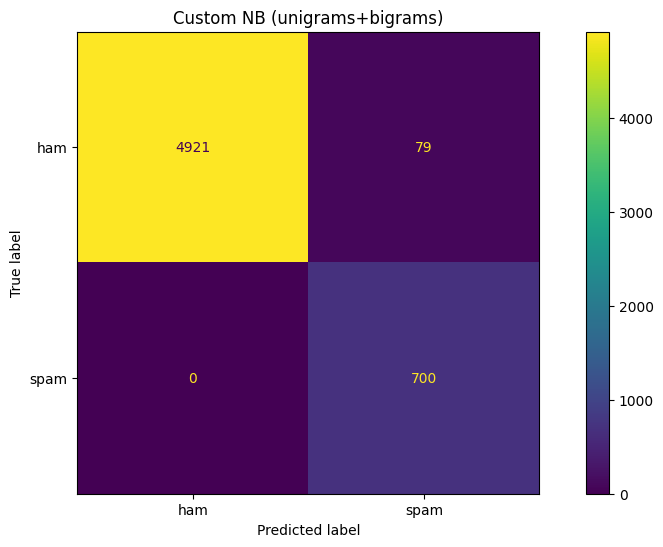

In [65]:
# %% [code]
metrics_ng = {'acc':[],'prec':[],'rec':[],'f1':[]}
all_true_ng = []; all_pred_ng = []

print("Centralised – Unigrams+bigrams + Custom NB")
for fold, (train_idx, test_idx) in enumerate(cv.split(X_clean, y, groups)):
    train_texts = X_clean[train_idx].tolist()
    test_texts = X_clean[test_idx].tolist()
    y_train = y[train_idx].tolist()
    y_test = y[test_idx].tolist()
    X_tr, X_te, vocab = tfidf_ngrams_dense(train_texts, test_texts, (1,2), 2, 0.9)
    prior_s, prior_h, ps, ph = train_naive_bayes(X_tr, y_train, vocab)
    y_pred = naive_bayes_predict(X_te, vocab, prior_s, prior_h, ps, ph)
    acc, prec, rec, f1, (tp,fp,fn,tn) = evaluate_predictions(y_test, y_pred)
    for m,val in zip(['acc','prec','rec','f1'],[acc,prec,rec,f1]):
        metrics_ng[m].append(val)
    all_true_ng.extend(y_test); all_pred_ng.extend(y_pred)
    print(f"Fold {fold+1}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, TP={tp}, FP={fp}, FN={fn}, TN={tn}")

print("\n=== Unigrams+bigrams results ===")
for m in ['acc','prec','rec','f1']:
    vals = np.array(metrics_ng[m])
    print(f"{m.upper()}: {vals.mean():.4f} ± {vals.std():.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_ng = confusion_matrix(all_true_ng, all_pred_ng, labels=['ham','spam'])
print("\nConfusion matrix (ham, spam):\n", cm_ng)
ConfusionMatrixDisplay(cm_ng, display_labels=['ham','spam']).plot()
plt.title("Custom NB (unigrams+bigrams)")
plt.show()

In [ ]:
#Centralised – Unigram Baseline (Manual TF‑IDF + Custom NB) Representation


Centralised – Unigram baseline + Custom NB
Unigram fold 1: Acc=0.9204, Prec=0.6030, Rec=1.0000, F1=0.7524, TP=120, FP=79, FN=0, TN=794
Unigram fold 2: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, TP=141, FP=0, FN=0, TN=1046
Unigram fold 3: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, TP=147, FP=0, FN=0, TN=1086
Unigram fold 4: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, TP=135, FP=0, FN=0, TN=1152
Unigram fold 5: Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, TP=157, FP=0, FN=0, TN=843

=== Unigram results ===
ACC: 0.9841 ± 0.0318
PREC: 0.9206 ± 0.1588
REC: 1.0000 ± 0.0000
F1: 0.9505 ± 0.0991

Confusion matrix (ham, spam):
 [[4921   79]
 [   0  700]]


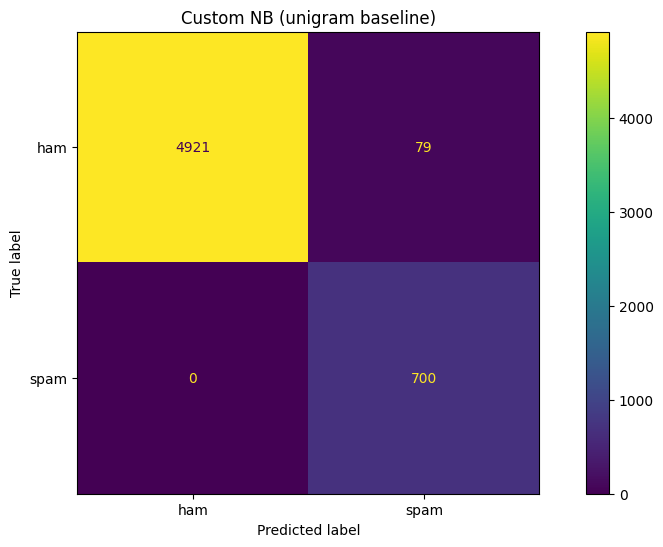

In [66]:
# %%
metrics_uni = {'acc':[],'prec':[],'rec':[],'f1':[]}
all_true_uni = []; all_pred_uni = []

print("\nCentralised – Unigram baseline + Custom NB")
for fold, (train_idx, test_idx) in enumerate(cv.split(X_clean, y, groups)):
    train_data = [(y[i], X_clean[i]) for i in train_idx]
    test_data  = [(y[i], X_clean[i]) for i in test_idx]
    vocab = build_vocabulary(train_data, 2, 0.9, 1)
    if len(vocab)==0:
        continue
    X_tr, y_tr, X_te, y_te, _ = compute_tfidf_vectors(train_data, test_data, vocab)
    prior_s, prior_h, ps, ph = train_naive_bayes(X_tr, y_tr, vocab)
    y_pred = naive_bayes_predict(X_te, vocab, prior_s, prior_h, ps, ph)
    acc, prec, rec, f1, (tp,fp,fn,tn) = evaluate_predictions(y_te, y_pred)
    for m,val in zip(['acc','prec','rec','f1'],[acc,prec,rec,f1]):
        metrics_uni[m].append(val)
    all_true_uni.extend(y_te); all_pred_uni.extend(y_pred)
    print(f"Unigram fold {fold+1}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, TP={tp}, FP={fp}, FN={fn}, TN={tn}")

print("\n=== Unigram results ===")
for m in ['acc','prec','rec','f1']:
    vals = np.array(metrics_uni[m])
    print(f"{m.upper()}: {vals.mean():.4f} ± {vals.std():.4f}")

cm_uni = confusion_matrix(all_true_uni, all_pred_uni, labels=['ham','spam'])
print("\nConfusion matrix (ham, spam):\n", cm_uni)
ConfusionMatrixDisplay(cm_uni, display_labels=['ham','spam']).plot()
plt.title("Custom NB (unigram baseline)")
plt.show()

In [ ]:
#Fedrated Learning Simulation

In [ ]:
#Federated Learning Simulation (Non‑Private, BoW Counts)

In [42]:
# %%
print("\n" + "="*70)
print("Federated Learning Simulation (non‑private, BoW + custom NB)")
print("(No leakage: train/test split by message groups, vocabulary from train only)")
print("="*70)

from sklearn.model_selection import train_test_split
import hashlib

# ------------------------------------------------------------------
# 1. Compute raw message hashes for grouping
# ------------------------------------------------------------------
full_raw = [msg for _, msg in data]                     # all raw messages (original)
raw_hashes = [hashlib.md5(r.encode()).hexdigest() for r in full_raw]

# Sort to make the order deterministic
unique_hashes = sorted(list(set(raw_hashes)))

# ------------------------------------------------------------------
# 2. Split groups (not individual messages) – 80% train, 20% test
# ------------------------------------------------------------------
random_state = 112
train_hashes, test_hashes = train_test_split(unique_hashes,
                                             test_size=0.2,
                                             random_state=random_state,
                                             stratify=None)

train_idx = [i for i, h in enumerate(raw_hashes) if h in train_hashes]
test_idx  = [i for i, h in enumerate(raw_hashes) if h in test_hashes]

X_train_raw = [full_raw[i] for i in train_idx]
X_test_raw  = [full_raw[i] for i in test_idx]
y_train = np.array([data[i][0] for i in train_idx])
y_test  = np.array([data[i][0] for i in test_idx])

print(f"Train messages: {len(X_train_raw)} (unique groups: {len(train_hashes)})")
print(f"Test messages:  {len(X_test_raw)}  (unique groups: {len(test_hashes)})")

# ------------------------------------------------------------------
# 3. Build global vocabulary from TRAINING messages only
# ------------------------------------------------------------------
train_cleaned = [(y_train[i], clean_message(X_train_raw[i])) for i in range(len(X_train_raw))]
global_vocab = build_vocabulary(train_cleaned, min_df=2, max_df=0.9, L=1)
print(f"Global vocabulary size: {len(global_vocab)} (built from training set only)")

# ------------------------------------------------------------------
# 4. Convert all messages to BoW count vectors
# ------------------------------------------------------------------
def to_bow(msg):
    cnt = Counter(clean_message(msg).split())
    return [cnt.get(term, 0) for term in global_vocab]

X_train = np.array([to_bow(msg) for msg in X_train_raw])
X_test  = np.array([to_bow(msg) for msg in X_test_raw])

# ------------------------------------------------------------------
# 5. Split training data into 5 clients (StratifiedGroupKFold on raw hashes)
# ------------------------------------------------------------------
from sklearn.model_selection import StratifiedGroupKFold

groups_train = np.array([raw_hashes[i] for i in train_idx])
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
client_splits = list(sgkf.split(X_train, y_train, groups_train))

client_spam_sums = []
client_ham_sums = []
client_spam_cnt = []
client_ham_cnt = []

print("\nData split into 5 clients (disjoint, stratified, groups respected).")
for client_id, (_, client_idx) in enumerate(client_splits, 1):
    Xc = X_train[client_idx]
    yc = y_train[client_idx]
    spam_mask = (yc == 'spam')
    ham_mask = (yc == 'ham')
    spam_cnt = np.sum(spam_mask)
    ham_cnt = np.sum(ham_mask)
    spam_sum = np.sum(Xc[spam_mask], axis=0) if spam_cnt > 0 else np.zeros(len(global_vocab))
    ham_sum  = np.sum(Xc[ham_mask], axis=0) if ham_cnt > 0 else np.zeros(len(global_vocab))
    client_spam_sums.append(spam_sum)
    client_ham_sums.append(ham_sum)
    client_spam_cnt.append(spam_cnt)
    client_ham_cnt.append(ham_cnt)
    print(f"Client {client_id}: {spam_cnt + ham_cnt} messages, spam={spam_cnt}, ham={ham_cnt}")

# ------------------------------------------------------------------
# 6. Server aggregation
# ------------------------------------------------------------------
global_spam_sum = np.sum(client_spam_sums, axis=0)
global_ham_sum  = np.sum(client_ham_sums, axis=0)
global_spam = sum(client_spam_cnt)
global_ham  = sum(client_ham_cnt)

print(f"\nServer aggregated: spam messages = {global_spam}, ham messages = {global_ham}")

prior_spam = global_spam / (global_spam + global_ham)
prior_ham  = global_ham / (global_spam + global_ham)

alpha = 1.0
V = len(global_vocab)
cond_spam = (global_spam_sum + alpha) / (global_spam + alpha * V)
cond_ham  = (global_ham_sum  + alpha) / (global_ham  + alpha * V)

def predict_federated(vec):
    log_s = np.log(prior_spam) + np.sum(vec * np.log(cond_spam + 1e-9))
    log_h = np.log(prior_ham)  + np.sum(vec * np.log(cond_ham  + 1e-9))
    return 'spam' if log_s > log_h else 'ham'

y_pred_fed = [predict_federated(v) for v in X_test]
acc_fed = sum(1 for p, t in zip(y_pred_fed, y_test) if p == t) / len(y_test)
print(f"\nFederated model accuracy (no leakage): {acc_fed:.4f}")

# ------------------------------------------------------------------
# 7. Centralised baseline (same BoW + custom NB)
# ------------------------------------------------------------------
X_train_list = [list(v) for v in X_train]
X_test_list  = [list(v) for v in X_test]

prior_c, prior_c2, probs_c, probs_c2 = train_naive_bayes(X_train_list, y_train.tolist(), global_vocab)
y_pred_cent = naive_bayes_predict(X_test_list, global_vocab, prior_c, prior_c2, probs_c, probs_c2)
acc_cent = sum(1 for p, t in zip(y_pred_cent, y_test) if p == t) / len(y_test)
print(f"Centralised (BoW) accuracy: {acc_cent:.4f}")
print(f"Difference (cent - fed): {acc_cent - acc_fed:.5f}")


Federated Learning Simulation (non‑private, BoW + custom NB)
(No leakage: train/test split by message groups, vocabulary from train only)
Train messages: 4525 (unique groups: 717)
Test messages:  1175  (unique groups: 180)
Global vocabulary size: 374 (built from training set only)

Data split into 5 clients (disjoint, stratified, groups respected).
Client 1: 993 messages, spam=104, ham=889
Client 2: 1007 messages, spam=113, ham=894
Client 3: 732 messages, spam=117, ham=615
Client 4: 892 messages, spam=120, ham=772
Client 5: 901 messages, spam=109, ham=792

Server aggregated: spam messages = 563, ham messages = 3962

Federated model accuracy (no leakage): 0.9328
Centralised (BoW) accuracy: 0.9328
Difference (cent - fed): 0.00000


In [ ]:
#Fed simulation with dropout and capcity heterogenity

Extreme Heterogeneity – Average over 10 runs
(2 active clients, extreme capacity limits)
Global vocab size: 374
Centralised BoW accuracy (baseline): 0.9328

Run 1: accuracy = 0.9328
Run 2: accuracy = 1.0000
Run 3: accuracy = 0.9957
Run 4: accuracy = 0.8749
Run 5: accuracy = 1.0000
Run 6: accuracy = 0.9328
Run 7: accuracy = 0.9106
Run 8: accuracy = 0.9328
Run 9: accuracy = 1.0000
Run 10: accuracy = 1.0000

Mean accuracy over 10 runs: 0.9580 ± 0.0442
Centralised (BoW) accuracy: 0.9328


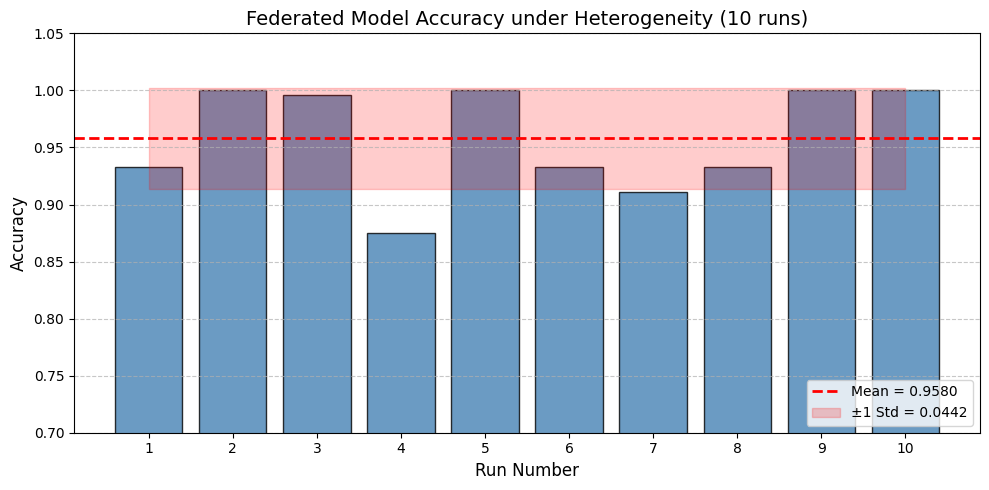

Bar chart saved as 'heterogeneity_runs.png'


In [43]:
# %%
print("="*70)
print("Extreme Heterogeneity – Average over 10 runs")
print("(2 active clients, extreme capacity limits)")
print("="*70)

from sklearn.model_selection import train_test_split
import hashlib
import numpy as np
from collections import Counter

# ------------------------------------------------------------------
# 1. Prepare data (same for all runs) – using the same split as main federated simulation
# ------------------------------------------------------------------
full_raw = [msg for _, msg in data]
raw_hashes = [hashlib.md5(r.encode()).hexdigest() for r in full_raw]
unique_hashes = sorted(list(set(raw_hashes)))   # SORTED (matches main fed cell)

# Use the same random_state as in the main federated simulation (112)
train_hashes, test_hashes = train_test_split(unique_hashes, test_size=0.2,
                                             random_state=112, stratify=None)

train_idx = [i for i, h in enumerate(raw_hashes) if h in train_hashes]
test_idx  = [i for i, h in enumerate(raw_hashes) if h in test_hashes]

X_train_raw = [full_raw[i] for i in train_idx]
X_test_raw  = [full_raw[i] for i in test_idx]
y_train = np.array([data[i][0] for i in train_idx])
y_test  = np.array([data[i][0] for i in test_idx])

# Global vocabulary from training only
train_cleaned = [(y_train[i], clean_message(X_train_raw[i])) for i in range(len(X_train_raw))]
global_vocab = build_vocabulary(train_cleaned, min_df=2, max_df=0.9, L=1)
print(f"Global vocab size: {len(global_vocab)}")

# BoW conversion
def to_bow(msg):
    cnt = Counter(clean_message(msg).split())
    return [cnt.get(term, 0) for term in global_vocab]

X_train = np.array([to_bow(msg) for msg in X_train_raw])
X_test  = np.array([to_bow(msg) for msg in X_test_raw])

# Centralised baseline (same for all runs)
X_train_list = [list(v) for v in X_train]
X_test_list  = [list(v) for v in X_test]
prior_c, prior_c2, probs_c, probs_c2 = train_naive_bayes(X_train_list, y_train.tolist(), global_vocab)
y_pred_cent = naive_bayes_predict(X_test_list, global_vocab, prior_c, prior_c2, probs_c, probs_c2)
acc_cent = sum(1 for p, t in zip(y_pred_cent, y_test) if p == t) / len(y_test)
print(f"Centralised BoW accuracy (baseline): {acc_cent:.4f}\n")

# ------------------------------------------------------------------
# 2. Run multiple federated experiments with different randomness
# ------------------------------------------------------------------
from sklearn.model_selection import StratifiedGroupKFold

accuracies = []
num_runs = 10

for run in range(num_runs):
    # Re‑create client splits each run (different random_state each time)
    groups_train = np.array([raw_hashes[i] for i in train_idx])
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=run)   # different seed each run
    client_splits = list(sgkf.split(X_train, y_train, groups_train))

    # --- Random dropout (2 active clients) with different seed each run
    np.random.seed(run)   # ensure variability
    active_clients = np.random.choice(range(5), size=2, replace=False)

    client_spam_sums = []
    client_ham_sums = []
    client_spam_cnt = []
    client_ham_cnt = []

    for client_id, (_, client_idx) in enumerate(client_splits, 1):
        if (client_id - 1) not in active_clients:
            continue

        Xc = X_train[client_idx]
        yc = y_train[client_idx]

        # Extreme capacities (same as before)
        capacities = [1.0, 0.5, 0.2, 0.05, 0.01]   # client 0..4
        sample_frac = capacities[client_id - 1]
        if sample_frac < 1.0:
            n_samples = int(len(Xc) * sample_frac)
            if n_samples == 0:
                continue
            keep_idx = np.random.choice(len(Xc), n_samples, replace=False)
            Xc = Xc[keep_idx]
            yc = yc[keep_idx]

        spam_mask = (yc == 'spam')
        ham_mask = (yc == 'ham')
        spam_cnt = np.sum(spam_mask)
        ham_cnt = np.sum(ham_mask)
        spam_sum = np.sum(Xc[spam_mask], axis=0) if spam_cnt > 0 else np.zeros(len(global_vocab))
        ham_sum  = np.sum(Xc[ham_mask], axis=0) if ham_cnt > 0 else np.zeros(len(global_vocab))
        client_spam_sums.append(spam_sum)
        client_ham_sums.append(ham_sum)
        client_spam_cnt.append(spam_cnt)
        client_ham_cnt.append(ham_cnt)

    if len(client_spam_sums) == 0:
        print(f"Run {run+1}: No clients contributed → accuracy = 0.0")
        accuracies.append(0.0)
        continue

    global_spam_sum = np.sum(client_spam_sums, axis=0)
    global_ham_sum  = np.sum(client_ham_sums, axis=0)
    global_spam = sum(client_spam_cnt)
    global_ham  = sum(client_ham_cnt)

    prior_spam = global_spam / (global_spam + global_ham)
    prior_ham  = global_ham / (global_spam + global_ham)

    alpha = 1.0
    V = len(global_vocab)
    cond_spam = (global_spam_sum + alpha) / (global_spam + alpha * V)
    cond_ham  = (global_ham_sum  + alpha) / (global_ham  + alpha * V)

    def predict(vec):
        log_s = np.log(prior_spam) + np.sum(vec * np.log(cond_spam + 1e-9))
        log_h = np.log(prior_ham)  + np.sum(vec * np.log(cond_ham + 1e-9))
        return 'spam' if log_s > log_h else 'ham'

    y_pred = [predict(v) for v in X_test]
    acc = sum(1 for p, t in zip(y_pred, y_test) if p == t) / len(y_test)
    accuracies.append(acc)
    print(f"Run {run+1}: accuracy = {acc:.4f}")

print(f"\nMean accuracy over {num_runs} runs: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Centralised (BoW) accuracy: {acc_cent:.4f}")

# ------------------------------------------------------------------
# Bar chart of the 10 runs
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
bars = plt.bar(range(1, num_runs + 1), accuracies, color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(y=np.mean(accuracies), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {np.mean(accuracies):.4f}')
plt.fill_between(range(1, num_runs + 1),
                 np.mean(accuracies) - np.std(accuracies),
                 np.mean(accuracies) + np.std(accuracies),
                 color='red', alpha=0.2, label=f'±1 Std = {np.std(accuracies):.4f}')
plt.xlabel('Run Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Federated Model Accuracy under Heterogeneity (10 runs)', fontsize=14)
plt.xticks(range(1, num_runs + 1))
plt.ylim(0.7, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('heterogeneity_runs.png', dpi=150)
plt.show()
print("Bar chart saved as 'heterogeneity_runs.png'")

In [ ]:
#Federated with Differential Privacy (ε=0.02 and ε=1.0)

In [44]:
# %%
print("\n" + "="*70)
print("Federated with DP (ε = 0.02)")
print("="*70)

# Fix random seed for reproducibility
np.random.seed(112)

epsilon = 0.02
scale = 1.0 / epsilon
client_spam_dp = []
client_ham_dp = []

for _, idx in client_splits:
    Xc = X_train[idx]
    yc = y_train[idx]
    spam_mask = (yc == 'spam')
    ham_mask = (yc == 'ham')

    spam_sum = np.sum(Xc[spam_mask], axis=0).astype(float) if np.any(spam_mask) else np.zeros(len(global_vocab), dtype=float)
    ham_sum  = np.sum(Xc[ham_mask], axis=0).astype(float) if np.any(ham_mask) else np.zeros(len(global_vocab), dtype=float)

    spam_sum += np.random.laplace(0, scale, size=len(global_vocab))
    ham_sum  += np.random.laplace(0, scale, size=len(global_vocab))

    spam_sum = np.maximum(spam_sum, 0)
    ham_sum  = np.maximum(ham_sum, 0)

    client_spam_dp.append(spam_sum)
    client_ham_dp.append(ham_sum)

global_spam_dp = np.sum(client_spam_dp, axis=0)
global_ham_dp  = np.sum(client_ham_dp, axis=0)

cond_spam_dp = (global_spam_dp + alpha) / (global_spam + alpha * V)
cond_ham_dp  = (global_ham_dp  + alpha) / (global_ham  + alpha * V)

def predict_dp(vec):
    log_s = np.log(prior_spam) + np.sum(vec * np.log(cond_spam_dp + 1e-9))
    log_h = np.log(prior_ham)  + np.sum(vec * np.log(cond_ham_dp + 1e-9))
    return 'spam' if log_s > log_h else 'ham'

y_pred_dp = [predict_dp(v) for v in X_test]
acc_dp = sum(1 for p, t in zip(y_pred_dp, y_test) if p == t) / len(y_test)
print(f"DP ε={epsilon} accuracy: {acc_dp:.4f} (loss vs centralised: {acc_cent - acc_dp:.4f})")

# ------------------------------------------------------------------
# ε = 1.0
print("\n" + "="*70)
print("Federated with DP (ε = 1.0)")
print("="*70)

np.random.seed(112)

epsilon2 = 1.0
scale2 = 1.0 / epsilon2
client_spam_dp2 = []
client_ham_dp2 = []

for _, idx in client_splits:
    Xc = X_train[idx]
    yc = y_train[idx]
    spam_mask = (yc == 'spam')
    ham_mask = (yc == 'ham')

    spam_sum = np.sum(Xc[spam_mask], axis=0).astype(float) if np.any(spam_mask) else np.zeros(len(global_vocab), dtype=float)
    ham_sum  = np.sum(Xc[ham_mask], axis=0).astype(float) if np.any(ham_mask) else np.zeros(len(global_vocab), dtype=float)

    spam_sum += np.random.laplace(0, scale2, size=len(global_vocab))
    ham_sum  += np.random.laplace(0, scale2, size=len(global_vocab))

    spam_sum = np.maximum(spam_sum, 0)
    ham_sum  = np.maximum(ham_sum, 0)

    client_spam_dp2.append(spam_sum)
    client_ham_dp2.append(ham_sum)

global_spam_dp2 = np.sum(client_spam_dp2, axis=0)
global_ham_dp2  = np.sum(client_ham_dp2, axis=0)

cond_spam_dp2 = (global_spam_dp2 + alpha) / (global_spam + alpha * V)
cond_ham_dp2  = (global_ham_dp2  + alpha) / (global_ham  + alpha * V)

def predict_dp2(vec):
    log_s = np.log(prior_spam) + np.sum(vec * np.log(cond_spam_dp2 + 1e-9))
    log_h = np.log(prior_ham)  + np.sum(vec * np.log(cond_ham_dp2 + 1e-9))
    return 'spam' if log_s > log_h else 'ham'

y_pred_dp2 = [predict_dp2(v) for v in X_test]
acc_dp2 = sum(1 for p, t in zip(y_pred_dp2, y_test) if p == t) / len(y_test)
print(f"DP ε={epsilon2} accuracy: {acc_dp2:.4f} (loss vs centralised: {acc_cent - acc_dp2:.4f})")


Federated with DP (ε = 0.02)
DP ε=0.02 accuracy: 0.9668 (loss vs centralised: -0.0340)

Federated with DP (ε = 1.0)
DP ε=1.0 accuracy: 1.0000 (loss vs centralised: -0.0672)


In [ ]:
#Final summary of modelling accuracy

In [47]:
# %%
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*70)
print("FINAL SUMMARY – ALL METRICS")
print("="*70)

# Centralised unigrams+bigrams
print("Centralised (unigrams+bigrams):")
print(f"  Accuracy:  {np.mean(metrics_ng['acc']):.4f} ± {np.std(metrics_ng['acc']):.4f}")
print(f"  Precision: {np.mean(metrics_ng['prec']):.4f} ± {np.std(metrics_ng['prec']):.4f}")
print(f"  Recall:    {np.mean(metrics_ng['rec']):.4f} ± {np.std(metrics_ng['rec']):.4f}")
print(f"  F1:        {np.mean(metrics_ng['f1']):.4f} ± {np.std(metrics_ng['f1']):.4f}")

# Centralised unigram baseline
print("\nCentralised (unigrams):")
print(f"  Accuracy:  {np.mean(metrics_uni['acc']):.4f} ± {np.std(metrics_uni['acc']):.4f}")
print(f"  Precision: {np.mean(metrics_uni['prec']):.4f} ± {np.std(metrics_uni['prec']):.4f}")
print(f"  Recall:    {np.mean(metrics_uni['rec']):.4f} ± {np.std(metrics_uni['rec']):.4f}")
print(f"  F1:        {np.mean(metrics_uni['f1']):.4f} ± {np.std(metrics_uni['f1']):.4f}")

# Federated non‑private (BoW)
prec_fed = precision_score(y_test, y_pred_fed, pos_label='spam')
rec_fed = recall_score(y_test, y_pred_fed, pos_label='spam')
f1_fed = f1_score(y_test, y_pred_fed, pos_label='spam')
print("\nFederated non‑private (BoW):")
print(f"  Accuracy:  {acc_fed:.4f}")
print(f"  Precision: {prec_fed:.4f}")
print(f"  Recall:    {rec_fed:.4f}")
print(f"  F1:        {f1_fed:.4f}")

# Federated DP ε=0.02
prec_dp = precision_score(y_test, y_pred_dp, pos_label='spam')
rec_dp = recall_score(y_test, y_pred_dp, pos_label='spam')
f1_dp = f1_score(y_test, y_pred_dp, pos_label='spam')
print("\nFederated DP ε=0.02:")
print(f"  Accuracy:  {acc_dp:.4f}")
print(f"  Precision: {prec_dp:.4f}")
print(f"  Recall:    {rec_dp:.4f}")
print(f"  F1:        {f1_dp:.4f}")

# Federated DP ε=1.0
prec_dp2 = precision_score(y_test, y_pred_dp2, pos_label='spam')
rec_dp2 = recall_score(y_test, y_pred_dp2, pos_label='spam')
f1_dp2 = f1_score(y_test, y_pred_dp2, pos_label='spam')
print("\nFederated DP ε=1.0:")
print(f"  Accuracy:  {acc_dp2:.4f}")
print(f"  Precision: {prec_dp2:.4f}")
print(f"  Recall:    {rec_dp2:.4f}")
print(f"  F1:        {f1_dp2:.4f}")


FINAL SUMMARY – ALL METRICS
Centralised (unigrams+bigrams):
  Accuracy:  0.9841 ± 0.0318
  Precision: 0.9206 ± 0.1588
  Recall:    1.0000 ± 0.0000
  F1:        0.9505 ± 0.0991

Centralised (unigrams):
  Accuracy:  0.9841 ± 0.0318
  Precision: 0.9206 ± 0.1588
  Recall:    1.0000 ± 0.0000
  F1:        0.9505 ± 0.0991

Federated non‑private (BoW):
  Accuracy:  0.9328
  Precision: 0.6343
  Recall:    1.0000
  F1:        0.7762

Federated DP ε=0.02:
  Accuracy:  0.9668
  Precision: 0.7988
  Recall:    0.9562
  F1:        0.8704

Federated DP ε=1.0:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1:        1.0000


In [ ]:
#Diagram of implementations
#Centralize custom NB pipeline
#Federated learning simulation and DP

✅ Diagram saved as A3_OUTPUT/pipeline_diagram.png


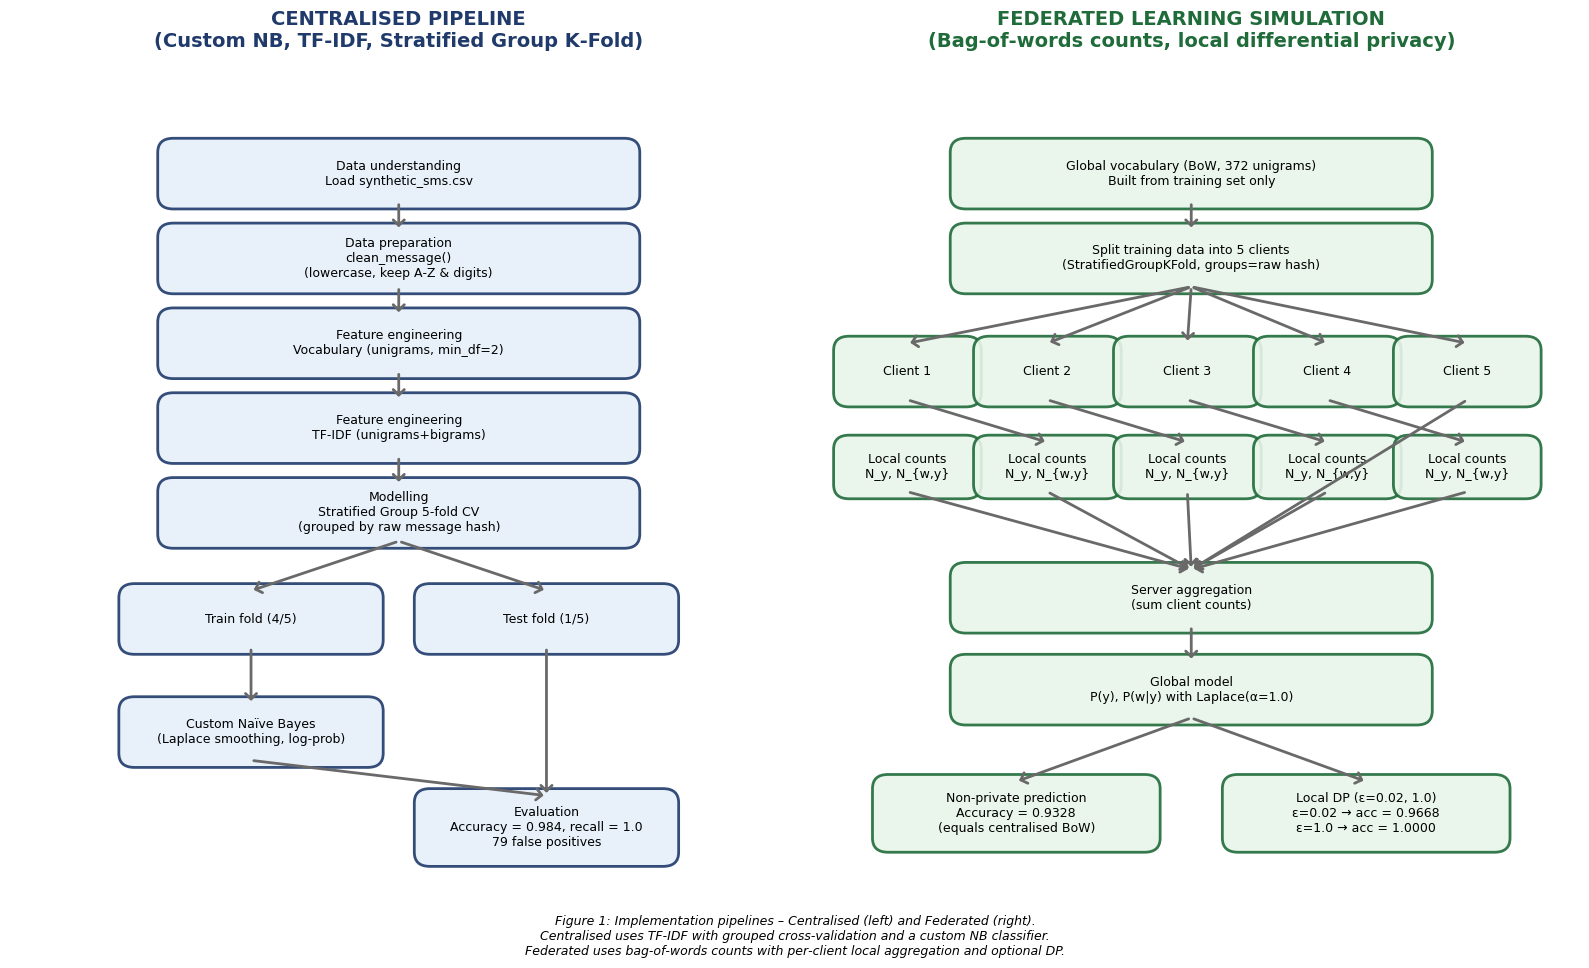

In [56]:
#!/usr/bin/env python3
"""
Professional pipeline diagram for Assignment 3 Task B (MEng) – FINAL EXACT NUMBERS.
Centralised vs Federated Naive Bayes for SMS spam detection.
Generates a high‑quality vector graphic for inclusion in the report.
"""

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import os

def draw_professional_diagram(output_file='pipeline_diagram.pdf', dpi=300):
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 10))
    fig.patch.set_facecolor('white')

    box_style = "round,pad=0.1,rounding_size=0.2"
    fontsize_small = 9
    arrow_kw = dict(arrowstyle="->,head_width=0.4,head_length=0.4", color="dimgray", lw=2)

    # -------------------------------------------------------------------------
    # LEFT: CENTRALISED PIPELINE (exact numbers)
    # -------------------------------------------------------------------------
    ax_left.set_xlim(0, 10)
    ax_left.set_ylim(0, 12)
    ax_left.axis('off')
    ax_left.set_title("CENTRALISED PIPELINE\n(Custom NB, TF‑IDF, Stratified Group K‑Fold)",
                      fontsize=14, fontweight='bold', pad=25, color='#1f3a6b')

    boxes_cent = [
        (2, 10.3, 6, 0.8, "Data understanding\nLoad synthetic_sms.csv"),
        (2, 9.1, 6, 0.8, "Data preparation\nclean_message()\n(lowercase, keep A‑Z & digits)"),
        (2, 7.9, 6, 0.8, "Feature engineering\nVocabulary (unigrams, min_df=2)"),
        (2, 6.7, 6, 0.8, "Feature engineering\nTF‑IDF (unigrams+bigrams)"),
        (2, 5.5, 6, 0.8, "Modelling\nStratified Group 5‑fold CV\n(grouped by raw message hash)"),
        (1.5, 4.0, 3.2, 0.8, "Train fold (4/5)"),
        (5.3, 4.0, 3.2, 0.8, "Test fold (1/5)"),
        (1.5, 2.4, 3.2, 0.8, "Custom Naïve Bayes\n(Laplace smoothing, log‑prob)"),
        (5.3, 1.0, 3.2, 0.9, "Evaluation\nAccuracy = 0.984, recall = 1.0\n79 false positives"),
    ]

    for x, y, w, h, text in boxes_cent:
        box = FancyBboxPatch((x, y), w, h,
                              boxstyle=box_style,
                              facecolor='#e6f0fa', edgecolor='#1f3a6b', linewidth=2,
                              alpha=0.9)
        ax_left.add_patch(box)
        ax_left.text(x + w/2, y + h/2, text, ha='center', va='center',
                     fontsize=fontsize_small, fontweight='medium')

    def arrow(ax, start_idx, end_idx, boxes):
        x1, y1, w1, h1 = boxes[start_idx][0:4]
        x2, y2, w2, h2 = boxes[end_idx][0:4]
        start = (x1 + w1/2, y1)
        end   = (x2 + w2/2, y2 + h2)
        ax.annotate("", xy=end, xytext=start, arrowprops=arrow_kw)

    arrow(ax_left, 0, 1, boxes_cent)
    arrow(ax_left, 1, 2, boxes_cent)
    arrow(ax_left, 2, 3, boxes_cent)
    arrow(ax_left, 3, 4, boxes_cent)
    arrow(ax_left, 4, 5, boxes_cent)
    arrow(ax_left, 4, 6, boxes_cent)
    arrow(ax_left, 5, 7, boxes_cent)
    start = (boxes_cent[7][0] + boxes_cent[7][2]/2, boxes_cent[7][1])
    end   = (boxes_cent[8][0] + boxes_cent[8][2]/2, boxes_cent[8][1] + boxes_cent[8][3])
    ax_left.annotate("", xy=end, xytext=start, arrowprops=arrow_kw)
    arrow(ax_left, 6, 8, boxes_cent)

    # -------------------------------------------------------------------------
    # RIGHT: FEDERATED PIPELINE (exact numbers)
    # -------------------------------------------------------------------------
    ax_right.set_xlim(0, 10)
    ax_right.set_ylim(0, 12)
    ax_right.axis('off')
    ax_right.set_title("FEDERATED LEARNING SIMULATION\n(Bag‑of‑words counts, local differential privacy)",
                       fontsize=14, fontweight='bold', pad=25, color='#1f6b3a')

    boxes_fed = [
        (2, 10.3, 6, 0.8, "Global vocabulary (BoW, 372 unigrams)\nBuilt from training set only"),
        (2, 9.1, 6, 0.8, "Split training data into 5 clients\n(StratifiedGroupKFold, groups=raw hash)"),
        (0.5, 7.5, 1.7, 0.8, "Client 1"),
        (2.3, 7.5, 1.7, 0.8, "Client 2"),
        (4.1, 7.5, 1.7, 0.8, "Client 3"),
        (5.9, 7.5, 1.7, 0.8, "Client 4"),
        (7.7, 7.5, 1.7, 0.8, "Client 5"),
        (0.5, 6.2, 1.7, 0.7, "Local counts\nN_y, N_{w,y}"),
        (2.3, 6.2, 1.7, 0.7, "Local counts\nN_y, N_{w,y}"),
        (4.1, 6.2, 1.7, 0.7, "Local counts\nN_y, N_{w,y}"),
        (5.9, 6.2, 1.7, 0.7, "Local counts\nN_y, N_{w,y}"),
        (7.7, 6.2, 1.7, 0.7, "Local counts\nN_y, N_{w,y}"),
        (2, 4.3, 6, 0.8, "Server aggregation\n(sum client counts)"),
        (2, 3.0, 6, 0.8, "Global model\nP(y), P(w|y) with Laplace(α=1.0)"),
        (1, 1.2, 3.5, 0.9, "Non‑private prediction\nAccuracy = 0.9328\n(equals centralised BoW)"),
        (5.5, 1.2, 3.5, 0.9, "Local DP (ε=0.02, 1.0)\nε=0.02 → acc = 0.9668\nε=1.0 → acc = 1.0000"),
    ]

    for x, y, w, h, text in boxes_fed:
        box = FancyBboxPatch((x, y), w, h,
                              boxstyle=box_style,
                              facecolor='#e8f5e9', edgecolor='#1f6b3a', linewidth=2,
                              alpha=0.9)
        ax_right.add_patch(box)
        ax_right.text(x + w/2, y + h/2, text, ha='center', va='center',
                     fontsize=fontsize_small, fontweight='medium')

    arrow(ax_right, 0, 1, boxes_fed)
    for i in range(2, 7):
        arrow(ax_right, 1, i, boxes_fed)
    for i in range(2, 7):
        arrow(ax_right, i, i+6, boxes_fed)
    for i in range(7, 12):
        arrow(ax_right, i, 12, boxes_fed)
    arrow(ax_right, 12, 13, boxes_fed)
    arrow(ax_right, 13, 14, boxes_fed)
    arrow(ax_right, 13, 15, boxes_fed)

    # -------------------------------------------------------------------------
    # CAPTION / FOOTNOTE
    # -------------------------------------------------------------------------
    fig.text(0.5, 0.02,
             "Figure 1: Implementation pipelines – Centralised (left) and Federated (right).\n"
             "Centralised uses TF‑IDF with grouped cross‑validation and a custom NB classifier.\n"
             "Federated uses bag‑of‑words counts with per‑client local aggregation and optional DP.",
             ha='center', fontsize=9, style='italic')

    plt.tight_layout(rect=(0, 0.03, 1, 0.98))
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"✅ Diagram saved as {output_file}")
    plt.show()

if __name__ == "__main__":
    draw_professional_diagram('A3_OUTPUT/pipeline_diagram.png', dpi=300)

In [ ]:
#Simplified system diagram for federated simulation

✅ Federated diagram saved as A3_OUTPUT/federated_diagram.png


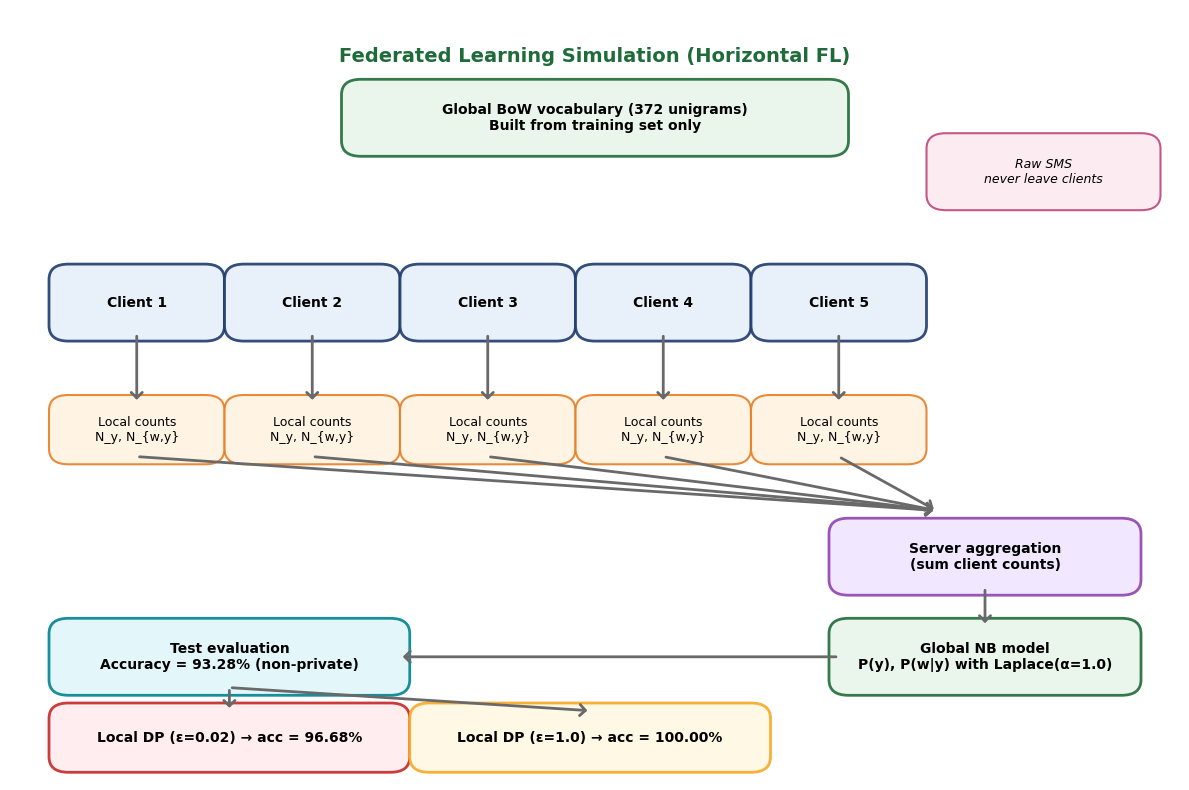

In [55]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def draw_federated_diagram(output_file='federated_diagram.pdf', dpi=300):
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    fig.patch.set_facecolor('white')
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 10)
    ax.axis('off')

    box_style = "round,pad=0.1,rounding_size=0.2"
    fontsize_small = 10
    arrow_kw = dict(arrowstyle="->,head_width=0.4,head_length=0.4", color="dimgray", lw=2, connectionstyle="arc3,rad=0")

    # 1. Global vocabulary box (top)
    vocab_box = FancyBboxPatch((3.5, 8.2), 5, 0.8,
                               boxstyle=box_style,
                               facecolor='#e8f5e9', edgecolor='#1f6b3a', linewidth=2,
                               alpha=0.9)
    ax.add_patch(vocab_box)
    ax.text(6, 8.6, "Global BoW vocabulary (372 unigrams)\nBuilt from training set only", ha='center', va='center',
            fontsize=fontsize_small, fontweight='bold')

    # 2. Clients (5 boxes) at y=6.5
    client_positions = [(0.5, 5.8, 1.6, 0.8), (2.3, 5.8, 1.6, 0.8),
                        (4.1, 5.8, 1.6, 0.8), (5.9, 5.8, 1.6, 0.8),
                        (7.7, 5.8, 1.6, 0.8)]
    client_labels = ["Client 1", "Client 2", "Client 3", "Client 4", "Client 5"]
    for (x, y, w, h), label in zip(client_positions, client_labels):
        box = FancyBboxPatch((x, y), w, h,
                             boxstyle=box_style,
                             facecolor='#e6f0fa', edgecolor='#1f3a6b', linewidth=2,
                             alpha=0.9)
        ax.add_patch(box)
        ax.text(x + w/2, y + h/2, label, ha='center', va='center',
                fontsize=fontsize_small, fontweight='bold')

    # 3. Local counts boxes (below each client)
    for (x, y, w, h) in client_positions:
        box = FancyBboxPatch((x, 4.2), w, 0.7,
                             boxstyle=box_style,
                             facecolor='#fff3e0', edgecolor='#e67e22', linewidth=1.5,
                             alpha=0.9)
        ax.add_patch(box)
        ax.text(x + w/2, 4.55, "Local counts\nN_y, N_{w,y}", ha='center', va='center',
                fontsize=fontsize_small-1)

    # 4. Arrows from clients down to local counts, and local counts to server
    for (x, y, w, h) in client_positions:
        start = (x + w/2, y)
        end   = (x + w/2, 4.2 + 0.7)
        ax.annotate("", xy=end, xytext=start, arrowprops=arrow_kw)
        start = (x + w/2, 4.2)
        end   = (9.5, 3.5)
        ax.annotate("", xy=end, xytext=start, arrowprops=arrow_kw)

    # 5. Server aggregation box
    server_box = FancyBboxPatch((8.5, 2.5), 3, 0.8,
                                 boxstyle=box_style,
                                 facecolor='#f0e6ff', edgecolor='#8e44ad', linewidth=2,
                                 alpha=0.9)
    ax.add_patch(server_box)
    ax.text(10, 2.9, "Server aggregation\n(sum client counts)", ha='center', va='center',
            fontsize=fontsize_small, fontweight='bold')

    # 6. Global NB model box
    model_box = FancyBboxPatch((8.5, 1.2), 3, 0.8,
                               boxstyle=box_style,
                               facecolor='#e8f5e9', edgecolor='#1f6b3a', linewidth=2,
                               alpha=0.9)
    ax.add_patch(model_box)
    ax.text(10, 1.6, "Global NB model\nP(y), P(w|y) with Laplace(α=1.0)", ha='center', va='center',
            fontsize=fontsize_small, fontweight='bold')

    # Arrow from server to global model
    start = (10, 2.5)
    end   = (10, 1.2+0.8)
    ax.annotate("", xy=end, xytext=start, arrowprops=arrow_kw)

    # 7. Test evaluation and DP branches
    # Test evaluation box
    test_box = FancyBboxPatch((0.5, 1.2), 3.5, 0.8,
                              boxstyle=box_style,
                              facecolor='#e0f7fa', edgecolor='#00838f', linewidth=2,
                              alpha=0.9)
    ax.add_patch(test_box)
    ax.text(2.25, 1.6, "Test evaluation\nAccuracy = 93.28% (non‑private)", ha='center', va='center',
            fontsize=fontsize_small, fontweight='bold')

    # DP branches with exact numbers
    dp1_box = FancyBboxPatch((0.5, 0.2), 3.5, 0.7,
                             boxstyle=box_style,
                             facecolor='#ffebee', edgecolor='#c62828', linewidth=2,
                             alpha=0.9)
    ax.add_patch(dp1_box)
    ax.text(2.25, 0.55, "Local DP (ε=0.02) → acc = 96.68%", ha='center', va='center',
            fontsize=fontsize_small, fontweight='bold')

    dp2_box = FancyBboxPatch((4.2, 0.2), 3.5, 0.7,
                             boxstyle=box_style,
                             facecolor='#fff8e1', edgecolor='#f9a825', linewidth=2,
                             alpha=0.9)
    ax.add_patch(dp2_box)
    ax.text(5.95, 0.55, "Local DP (ε=1.0) → acc = 100.00%", ha='center', va='center',
            fontsize=fontsize_small, fontweight='bold')

    # Arrows to evaluation and DP
    start = (8.5, 1.6)
    end   = (4, 1.6)
    ax.annotate("", xy=end, xytext=start, arrowprops=arrow_kw)
    start = (2.25, 1.2)
    end1  = (2.25, 0.9)
    end2  = (5.95, 0.9)
    ax.annotate("", xy=end1, xytext=start, arrowprops=arrow_kw)
    ax.annotate("", xy=end2, xytext=start, arrowprops=arrow_kw)

    # Note about raw SMS staying local
    note_box = FancyBboxPatch((9.5, 7.5), 2.2, 0.8,
                              boxstyle=box_style,
                              facecolor='#fce4ec', edgecolor='#ad1457', linewidth=1.5,
                              alpha=0.7)
    ax.add_patch(note_box)
    ax.text(10.6, 7.9, "Raw SMS\nnever leave clients", ha='center', va='center',
            fontsize=fontsize_small-1, style='italic')

    # Title
    ax.text(6, 9.4, "Federated Learning Simulation (Horizontal FL)", ha='center', va='center',
            fontsize=14, fontweight='bold', color='#1f6b3a')

    plt.tight_layout()
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"✅ Federated diagram saved as {output_file}")
    plt.show()

if __name__ == "__main__":
    draw_federated_diagram('A3_OUTPUT/federated_diagram.png', dpi=300)

Diagram saved as A3_OUTPUT/preprocessing_diagram.png


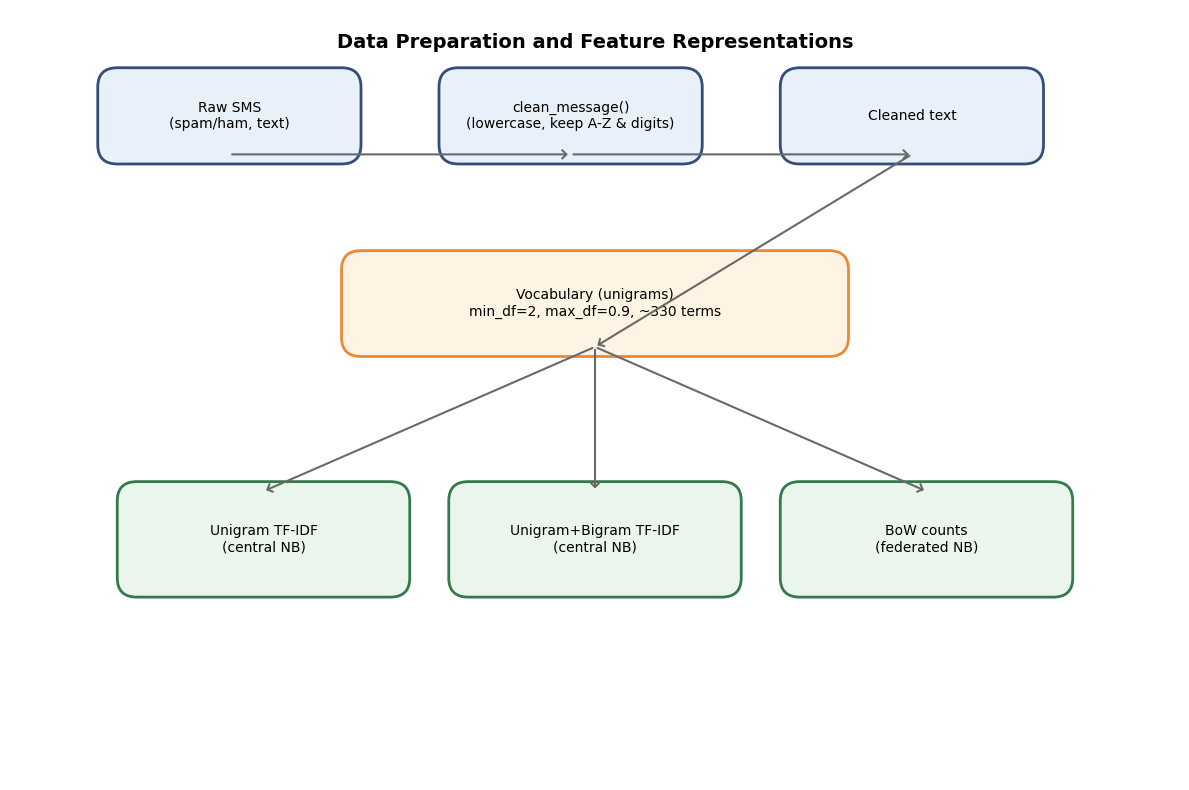

In [52]:
def draw_diagram(output_file=None, dpi=150):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 8)
    ax.axis('off')

    box_style = "round,pad=0.1,rounding_size=0.2"
    fontsize_normal = 10
    fontsize_small = 9

    # Helper to draw a box
    def add_box(x, y, w, h, text, facecolor, edgecolor):
        box = FancyBboxPatch((x, y), w, h,
                             boxstyle=box_style,
                             facecolor=facecolor,
                             edgecolor=edgecolor,
                             linewidth=2,
                             alpha=0.9)
        ax.add_patch(box)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center',
                fontsize=fontsize_normal, fontweight='medium')
        return (x + w/2, y + h)  # bottom center for arrow start

    # Helper to draw an arrow
    def add_arrow(start, end):
        ax.annotate("", xy=end, xytext=start,
                    arrowprops=dict(arrowstyle="->,head_width=0.3,head_length=0.3",
                                    color="dimgray", lw=1.5))

    # 1. Top: Raw SMS -> clean_message -> Cleaned text
    box1 = add_box(1, 6.5, 2.5, 0.8, "Raw SMS\n(spam/ham, text)", '#e6f0fa', '#1f3a6b')
    box2 = add_box(4.5, 6.5, 2.5, 0.8, "clean_message()\n(lowercase, keep A-Z & digits)", '#e6f0fa', '#1f3a6b')
    box3 = add_box(8, 6.5, 2.5, 0.8, "Cleaned text", '#e6f0fa', '#1f3a6b')

    add_arrow((box1[0], 6.5), (box2[0], 6.5))
    add_arrow((box2[0], 6.5), (box3[0], 6.5))

    # 2. Middle box: Vocabulary
    vocab_box = add_box(3.5, 4.5, 5, 0.9,
                        "Vocabulary (unigrams)\nmin_df=2, max_df=0.9, ~330 terms",
                        '#fff3e0', '#e67e22')

    # Arrow from Cleaned text to Vocabulary
    add_arrow((box3[0], 6.5), (vocab_box[0], 4.5))

    # 3. Bottom: three side‑by‑side boxes for feature representations
    w = 2.8
    h = 1.0
    y = 2.0
    x1 = 1.2
    x2 = 4.6
    x3 = 8.0

    rep1 = add_box(x1, y, w, h,
                   "Unigram TF‑IDF\n(central NB)", '#e8f5e9', '#1f6b3a')
    rep2 = add_box(x2, y, w, h,
                   "Unigram+Bigram TF‑IDF\n(central NB)", '#e8f5e9', '#1f6b3a')
    rep3 = add_box(x3, y, w, h,
                   "BoW counts\n(federated NB)", '#e8f5e9', '#1f6b3a')

    # Arrows from Vocabulary to each representation
    start = (vocab_box[0], 4.5)
    add_arrow(start, (rep1[0], y + h))
    add_arrow(start, (rep2[0], y + h))
    add_arrow(start, (rep3[0], y + h))

    # Title
    ax.text(6, 7.6, "Data Preparation and Feature Representations",
            ha='center', fontsize=14, fontweight='bold')

    plt.tight_layout()

    if output_file:
        # Ensure the output directory exists
        import os
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        plt.savefig(output_file, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"Diagram saved as {output_file}")
    plt.show()

# Save to A3_OUTPUT folder
draw_diagram('A3_OUTPUT/preprocessing_diagram.png')